# Visual changes in lesions

In [5]:
import os
import re
import pandas as pd
from collections import defaultdict

main_folder_path = r"E:\DATA_FollowUp"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]
patients = {img: defaultdict(list) for img in image_types}

pattern = r"Myel_FollowUp_(\d+)_(\d+)"

for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if match:
        patient_id = match.group(1)
        followup_number = int(match.group(2))

        folder_path = os.path.join(main_folder_path, folder)
        for file in os.listdir(folder_path):
            if file.endswith(".csv") and "radiomics_lesions_features" in file:
                for img in image_types:
                    if img in file:
                        csv_path = os.path.join(folder_path, file)
                        patients[img][patient_id].append((followup_number, csv_path))


patient_dates = {
    "001": ["12-05-2022", "25-04-2023", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024", "04-06-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    "008": ["23-10-2023", "20-02-2024", "14-08-2024", "01-04-2025"],
}

patient_follow_up_dfs = {}

for img_type, patient_data in patients.items():
    patient_follow_up_dfs[img_type] = {}

    for patient, scans in patient_data.items():
        scans = sorted(scans, key=lambda x: x[0])
        patient_follow_up_dfs[img_type][patient] = {}

        for i, (followup, path) in enumerate(scans):
            df = pd.read_csv(path)
            df["Date"] = patient_dates[patient][i]
            patient_follow_up_dfs[img_type][patient][followup] = df

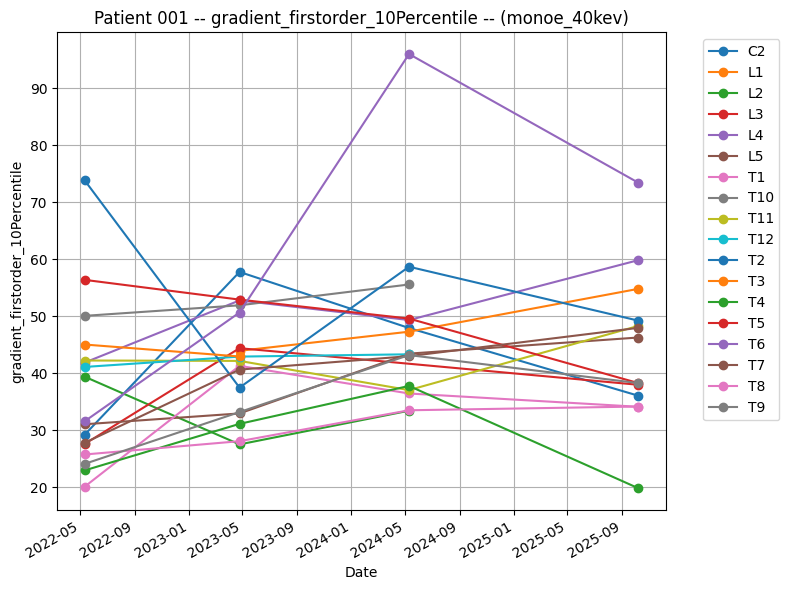

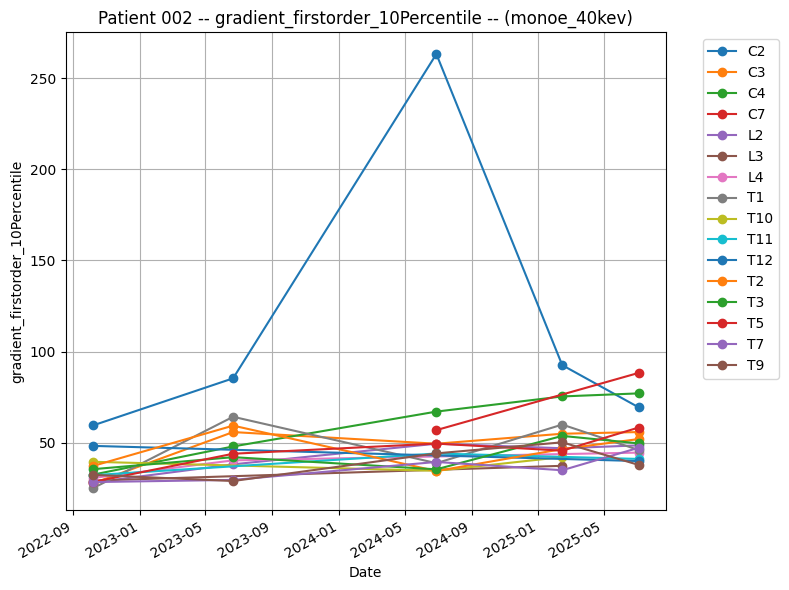

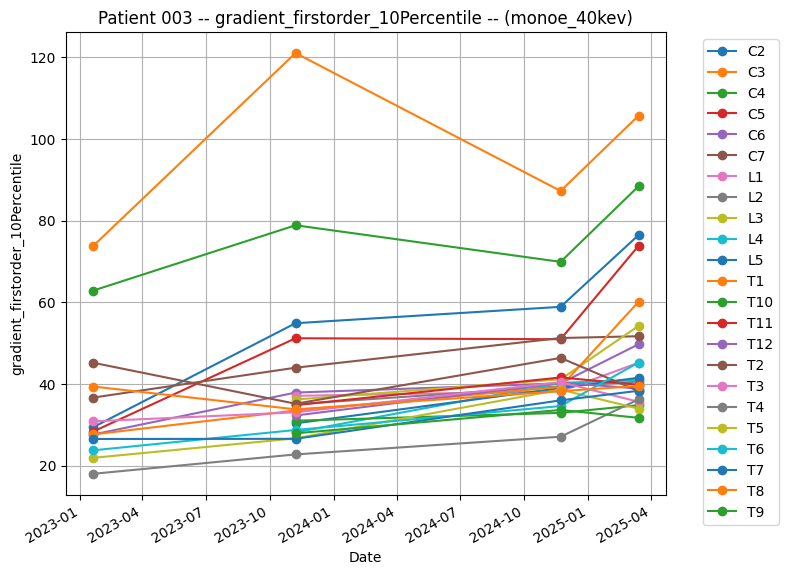

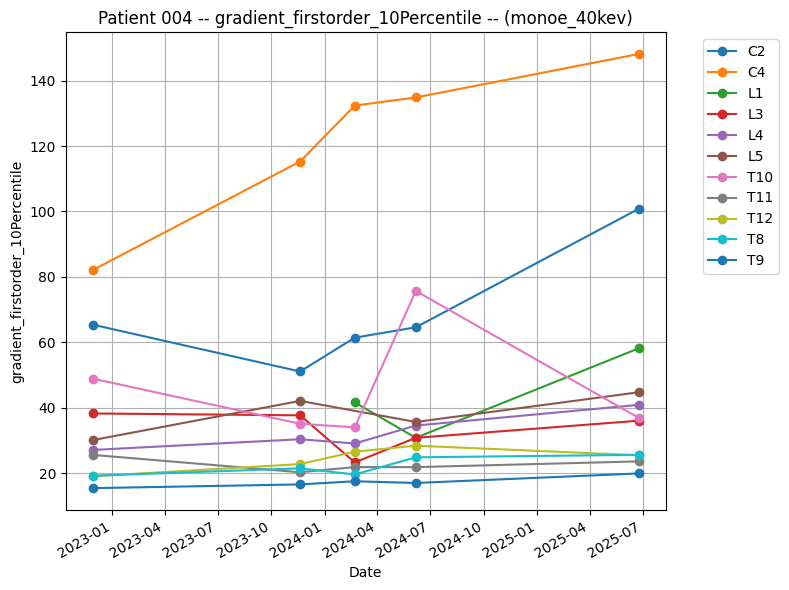

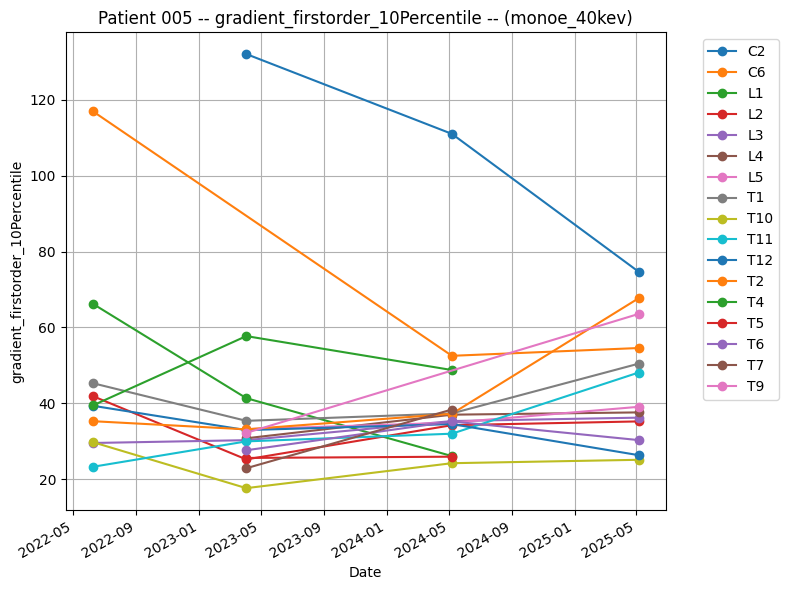

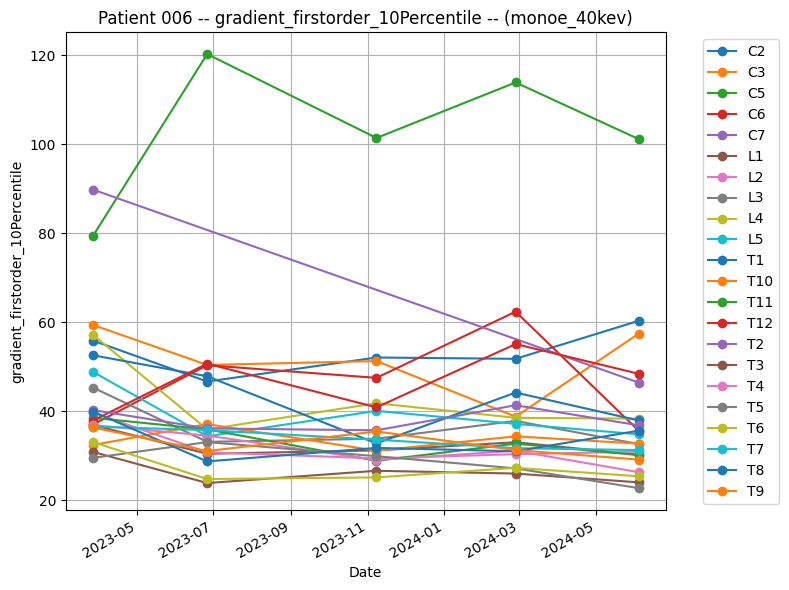

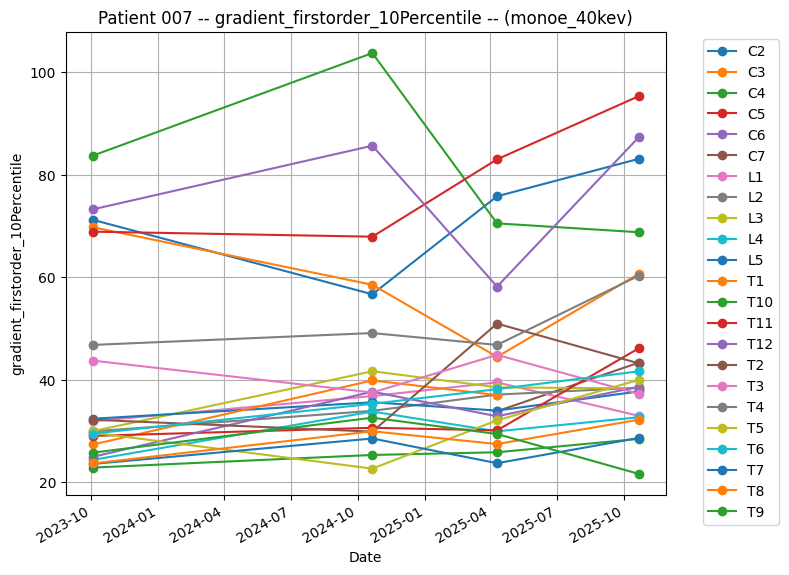

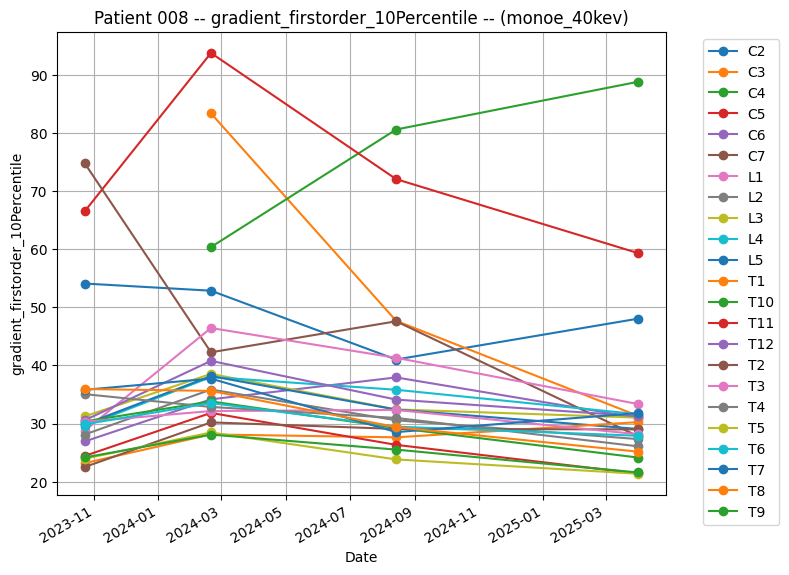

In [6]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd

img_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"
vertebra_col = "vertebra_name"

for patient, followups in patient_follow_up_dfs[img_type].items():

    plt.figure(figsize=(8,6))
    all_vertebrae = set()

    for df in followups.values():
        all_vertebrae.update(df[vertebra_col].unique())

    for vertebra in sorted(all_vertebrae):
        dates = []
        values = []
        for followup, df in sorted(followups.items()):
            df = df.copy()
            row = df[df[vertebra_col] == vertebra]

            if row.empty:
                continue

            date = pd.to_datetime(row["Date"].iloc[0], dayfirst=True)
            value = row[feature].iloc[0]

            dates.append(date)
            values.append(value)

        if len(dates) > 1:
            plt.plot(dates, values, marker="o", label=vertebra)

    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient {patient} -- {feature} -- ({img_type})")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

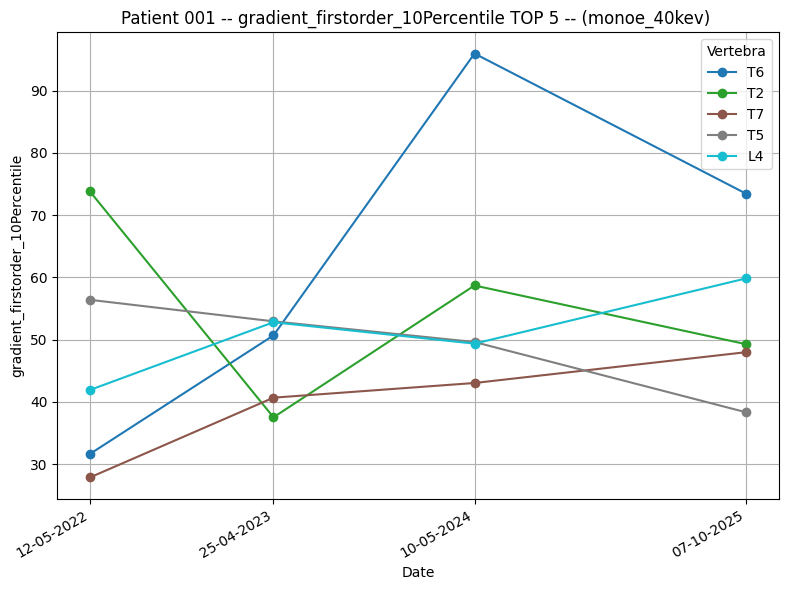

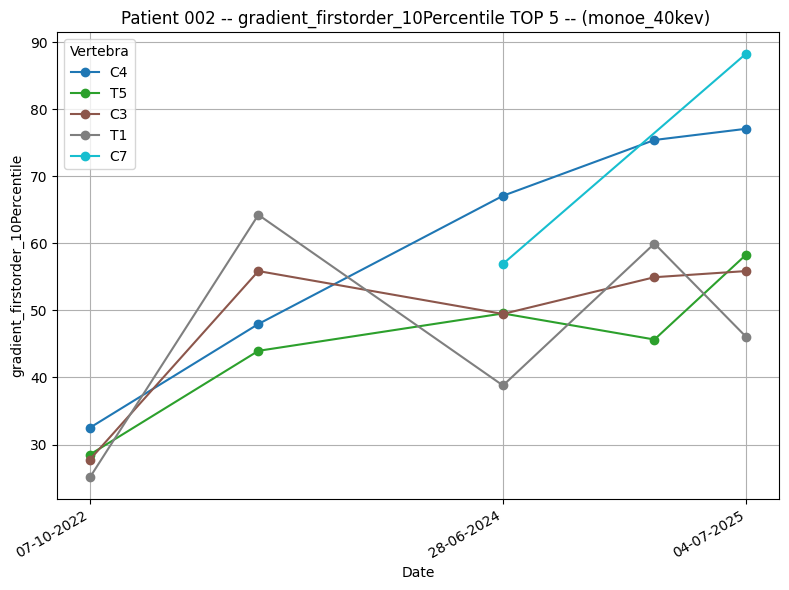

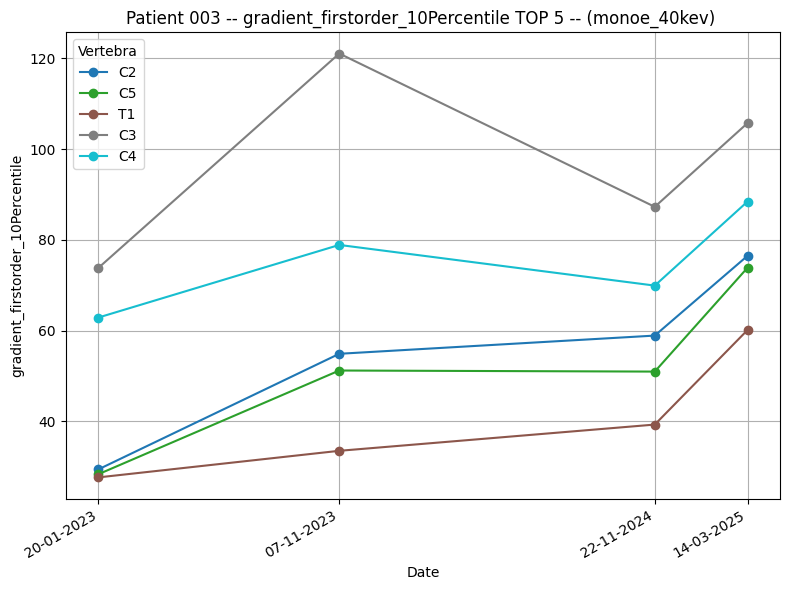

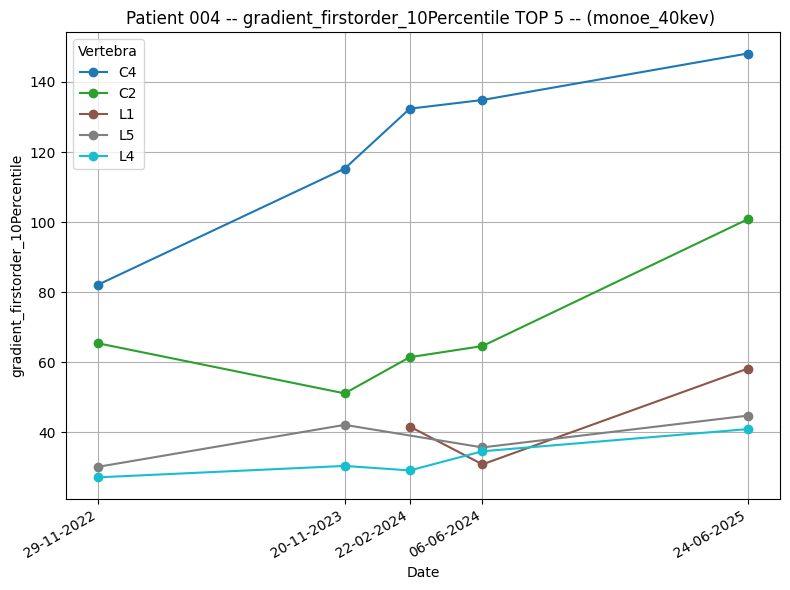

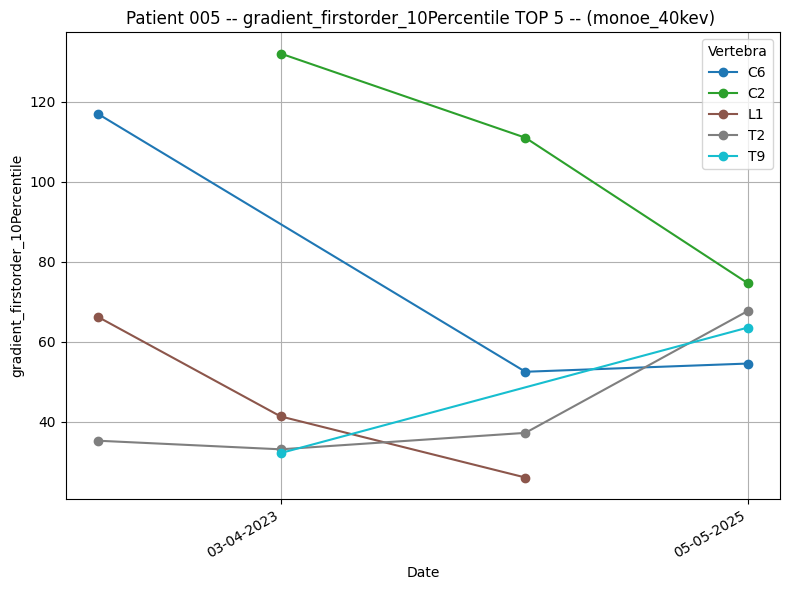

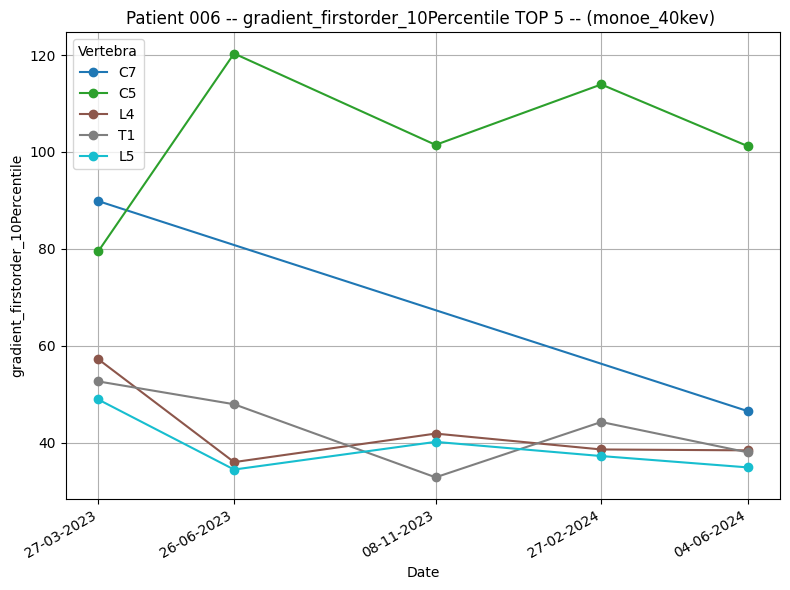

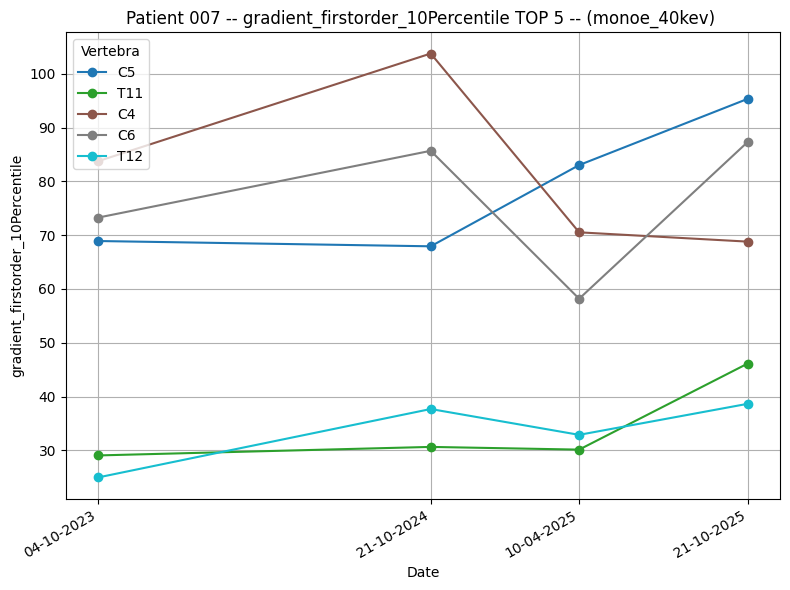

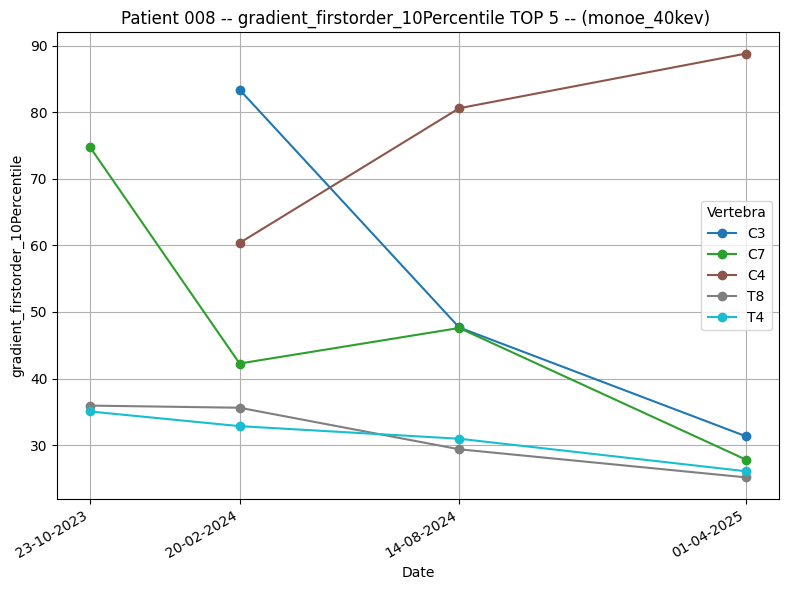

In [7]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd
import matplotlib

img_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"
vertebra_col = "vertebra_name"

for patient, followups in patient_follow_up_dfs[img_type].items():

    all_vertebrae = set()
    for df in followups.values():
        all_vertebrae.update(df[vertebra_col].unique())

    vertebra_changes = []
    for vertebra in all_vertebrae:
        values = []

        for followup, df in sorted(followups.items()):
            row = df[df[vertebra_col] == vertebra]
            if not row.empty:
                values.append(row[feature].mean())

        if len(values) > 1:
            change = abs(values[-1] - values[0])
            vertebra_changes.append((vertebra, change))

    top_vertebrae = [v[0] for v in sorted(vertebra_changes, key=lambda x: x[1], reverse=True)[:5]]
    colors = matplotlib.colormaps["tab10"].resampled(len(top_vertebrae))

    plt.figure(figsize=(8,6))
    for i, vertebra in enumerate(top_vertebrae):
        dates = []
        values = []

        for followup, df in sorted(followups.items()):
            row = df[df[vertebra_col] == vertebra]
            if not row.empty:
                dates.append(pd.to_datetime(row["Date"].iloc[0], dayfirst=True))
                values.append(row[feature].mean())

        plt.plot(dates, values, marker="o", label=vertebra, color=colors(i))
    plt.xticks(dates, [d.strftime("%d-%m-%Y") for d in dates])
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient {patient} -- {feature} TOP 5 -- ({img_type}) ")
    plt.legend(title="Vertebra")
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

median + mean hodnota cez obratle

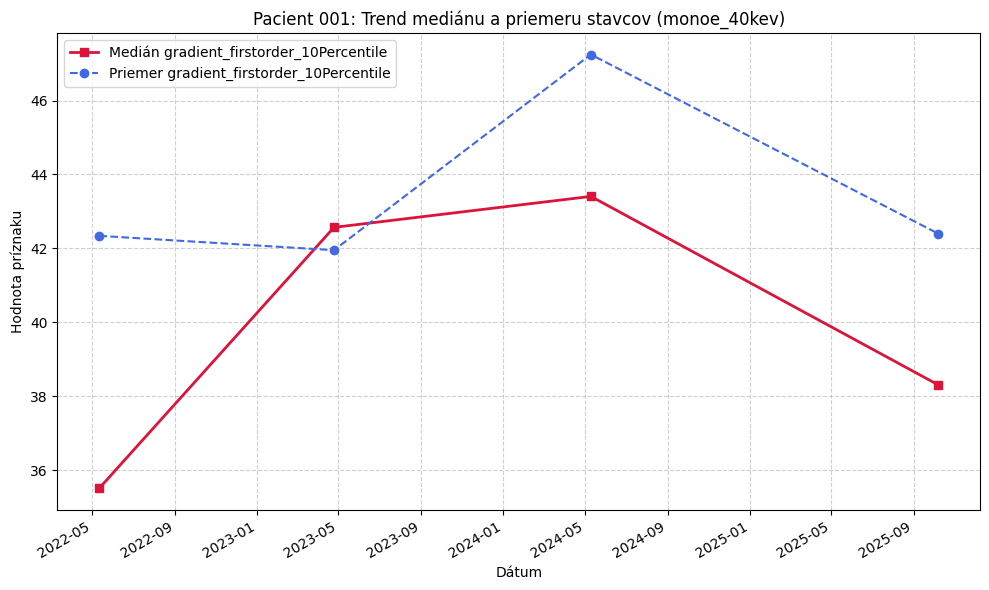

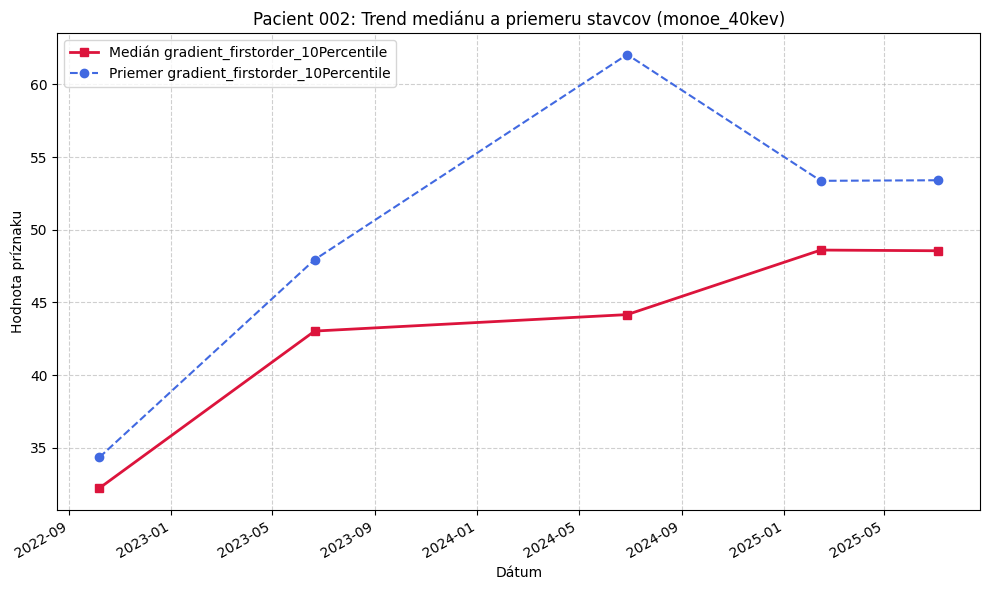

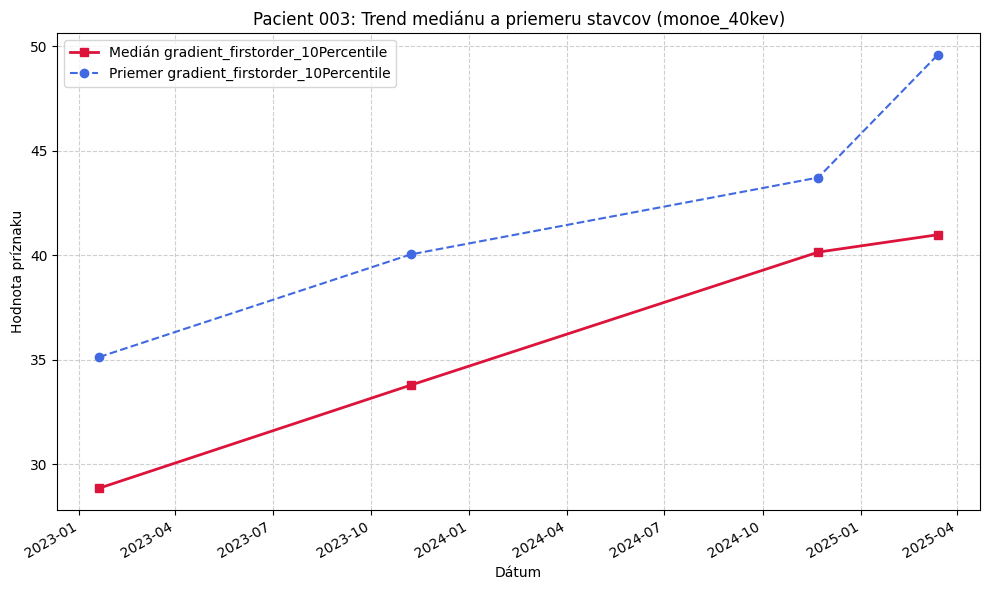

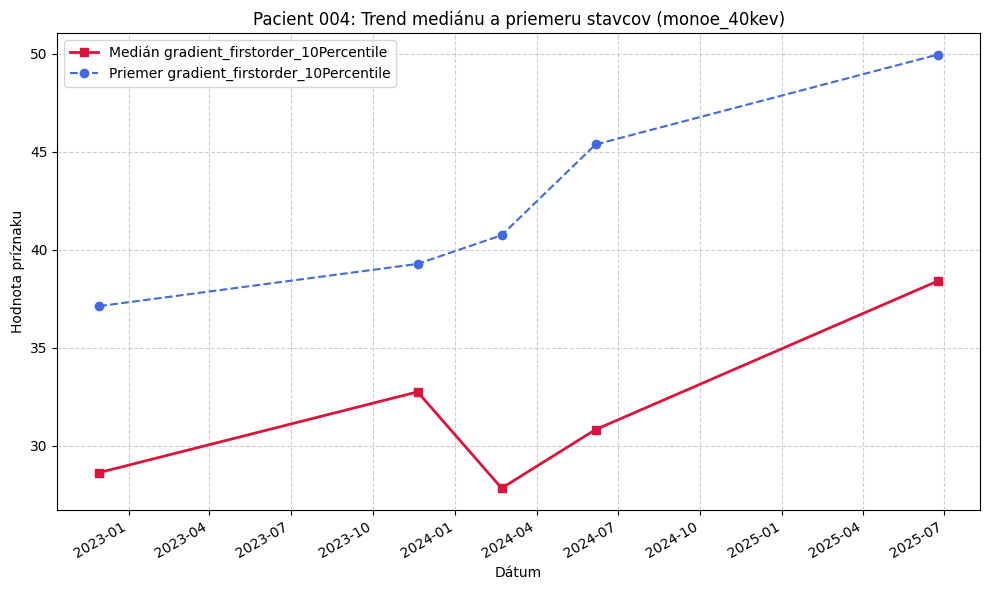

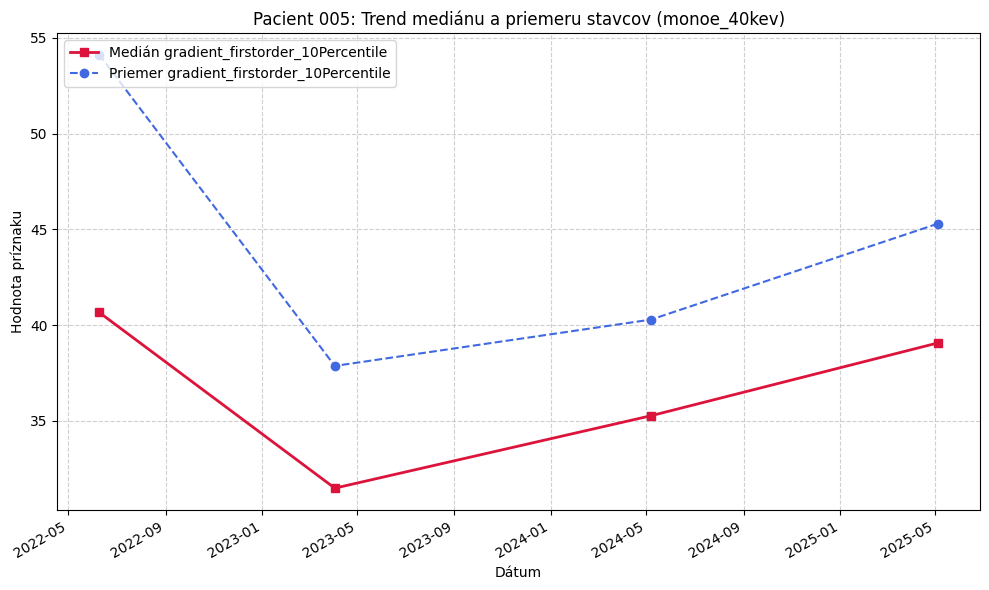

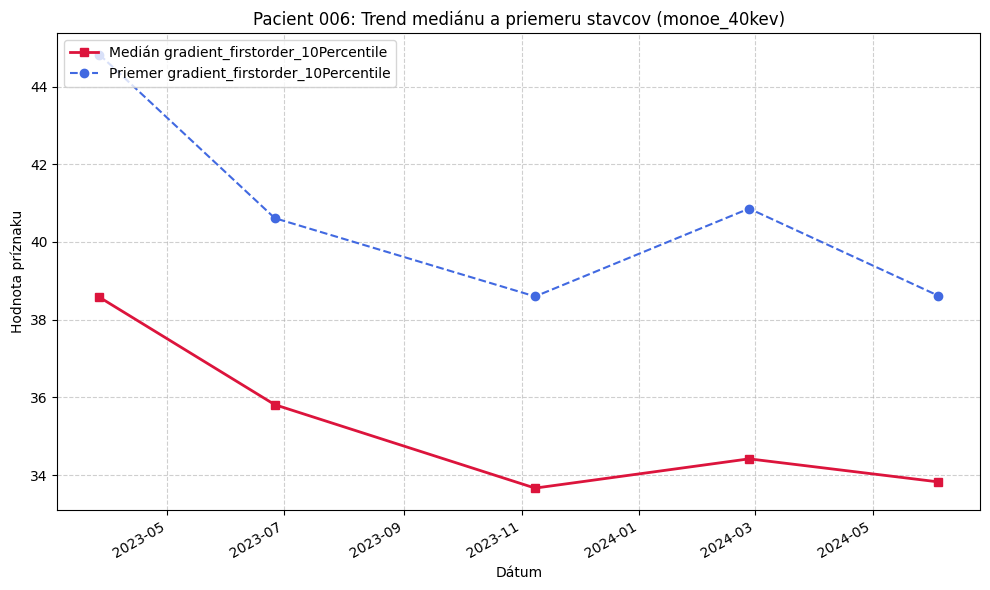

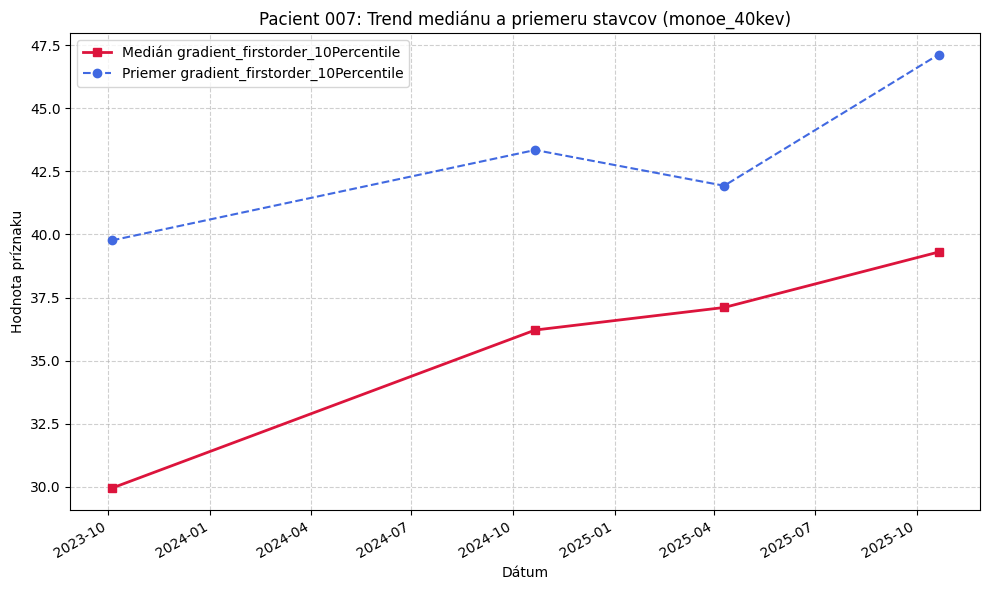

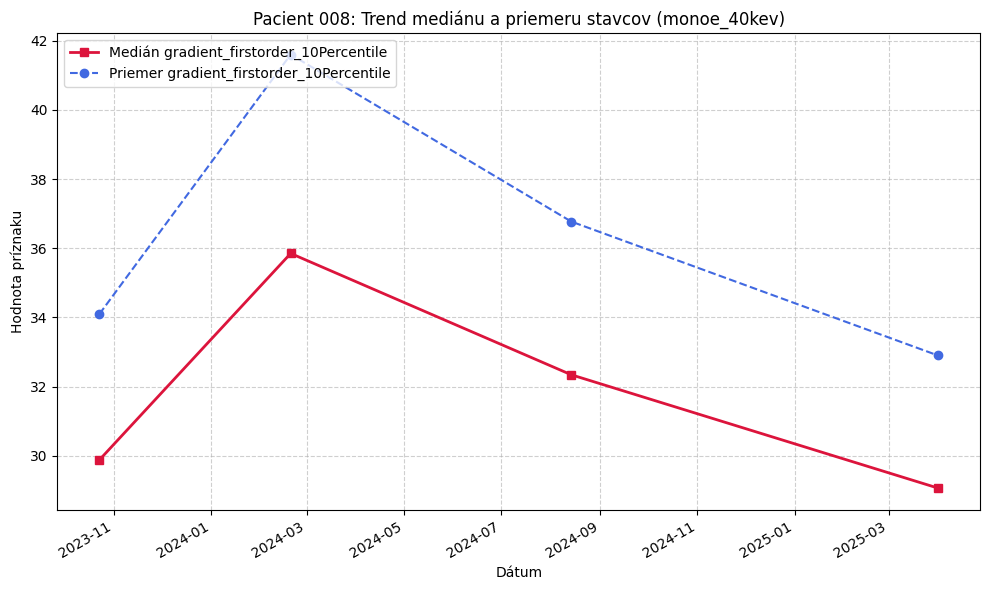

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Nastavenia
plt.style.use('default')
img_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"
vertebra_col = "vertebra_name"

for patient, followups in patient_follow_up_dfs[img_type].items():
    dates = []
    medians = []
    means = []  # Nový zoznam pre priemery

    for followup_id, df in sorted(followups.items()):
        if df.empty:
            continue

        # Výpočet štatistík
        current_median = df[feature].median()
        current_mean = df[feature].mean()  # Výpočet priemeru

        date = pd.to_datetime(df["Date"].iloc[0], dayfirst=True)

        dates.append(date)
        medians.append(current_median)
        means.append(current_mean)

    if dates:
        plt.figure(figsize=(10, 6))

        # Vykreslenie mediánu
        plt.plot(dates, medians, marker="s", linestyle="-", color="crimson",
                 linewidth=2, label=f"Medián {feature}")

        # Vykreslenie priemeru (čarkovaná čiara, iná farba)
        plt.plot(dates, means, marker="o", linestyle="--", color="royalblue",
                 linewidth=1.5, label=f"Priemer {feature}")

        plt.xlabel("Dátum")
        plt.ylabel("Hodnota príznaku")
        plt.title(f"Pacient {patient}: Trend mediánu a priemeru stavcov ({img_type})")

        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc="upper left")

        plt.gcf().autofmt_xdate()
        plt.tight_layout()
        plt.show()

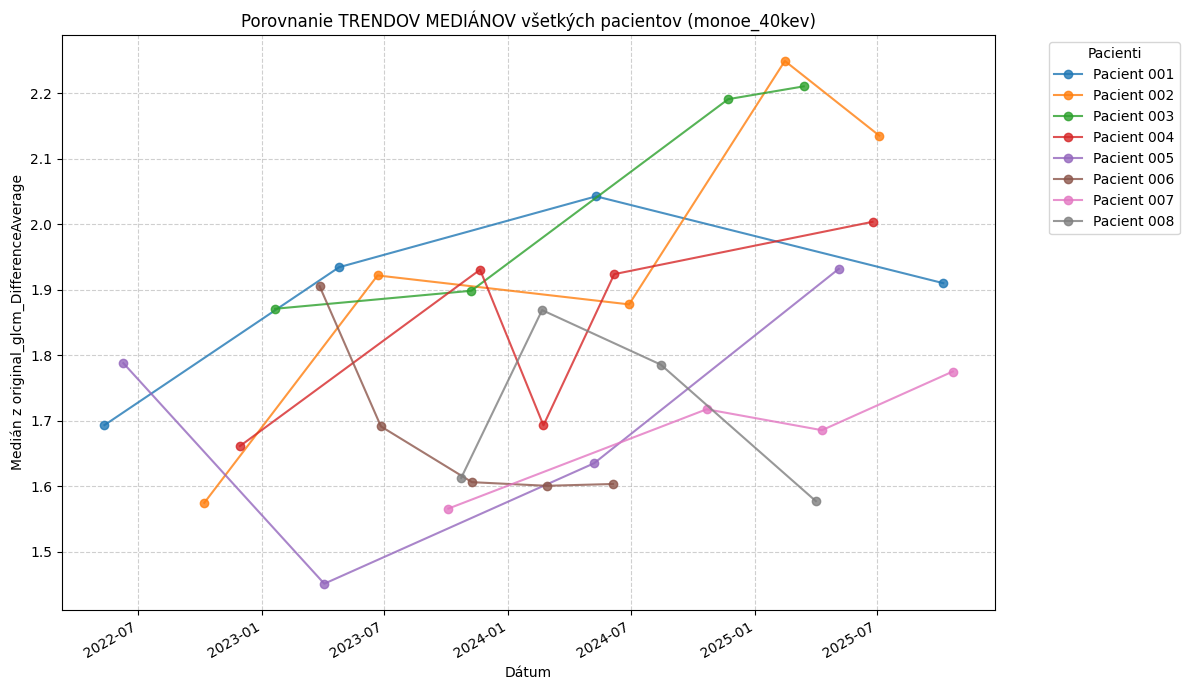

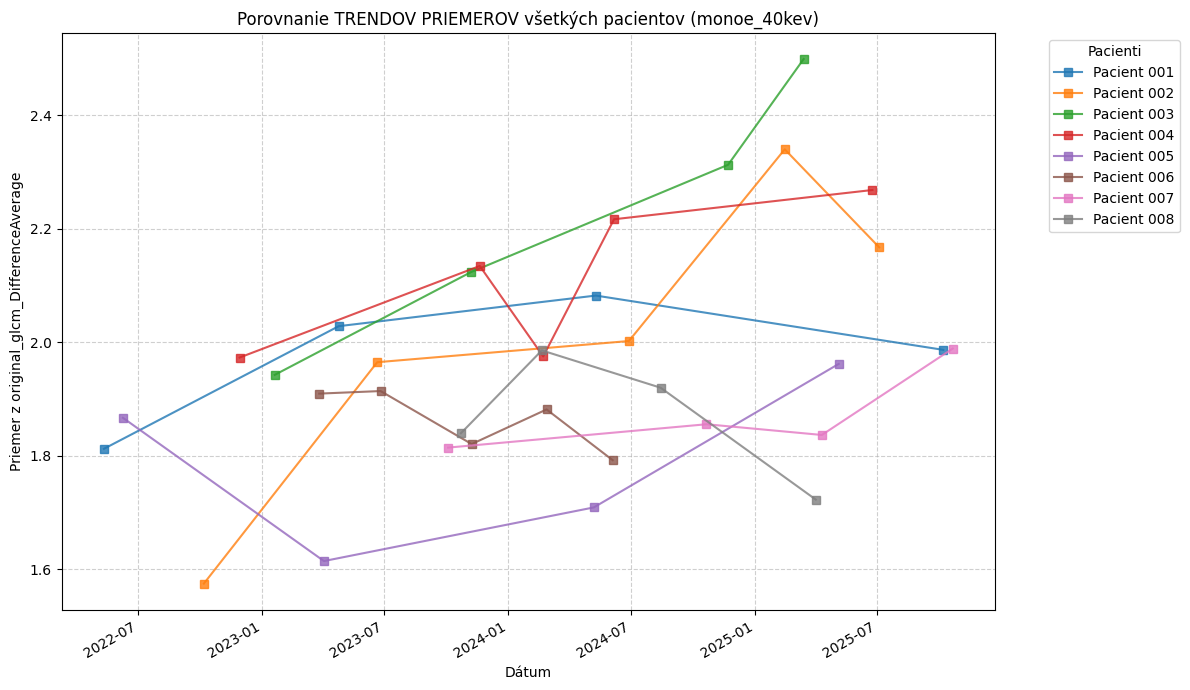

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Nastavenia
plt.style.use('default')
img_type = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"

# 1. Inicializácia dvoch samostatných grafov
fig_median, ax_median = plt.subplots(figsize=(12, 7))
fig_mean, ax_mean = plt.subplots(figsize=(12, 7))

for patient, followups in patient_follow_up_dfs[img_type].items():
    dates = []
    medians = []
    means = []

    # Zoradíme follow-upy chronologicky
    for followup_id, df in sorted(followups.items()):
        if df.empty:
            continue

        # Výpočet štatistík pre daný followup
        current_median = df[feature].median()
        current_mean = df[feature].mean()

        # Spracovanie dátumu
        date = pd.to_datetime(df["Date"].iloc[0], dayfirst=True)

        dates.append(date)
        medians.append(current_median)
        means.append(current_mean)

    if dates:
        # Vykreslenie do grafu pre Medián
        ax_median.plot(dates, medians, marker="o", linestyle="-",
                       label=f"Pacient {patient}", alpha=0.8)

        # Vykreslenie do grafu pre Priemer
        ax_mean.plot(dates, means, marker="s", linestyle="-",
                     label=f"Pacient {patient}", alpha=0.8)

# --- Formátovanie grafu pre MEDIÁN ---
ax_median.set_xlabel("Dátum")
ax_median.set_ylabel(f"Medián z {feature}")
ax_median.set_title(f"Porovnanie TRENDOV MEDIÁNOV všetkých pacientov ({img_type})")
ax_median.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Pacienti")
ax_median.grid(True, linestyle='--', alpha=0.6)
fig_median.autofmt_xdate()
fig_median.tight_layout()

# --- Formátovanie grafu pre PRIEMER ---
ax_mean.set_xlabel("Dátum")
ax_mean.set_ylabel(f"Priemer z {feature}")
ax_mean.set_title(f"Porovnanie TRENDOV PRIEMEROV všetkých pacientov ({img_type})")
ax_mean.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Pacienti")
ax_mean.grid(True, linestyle='--', alpha=0.6)
fig_mean.autofmt_xdate()
fig_mean.tight_layout()

# Zobrazenie oboch grafov
plt.show()

boxplot analyza outliers follow up - vertebra level

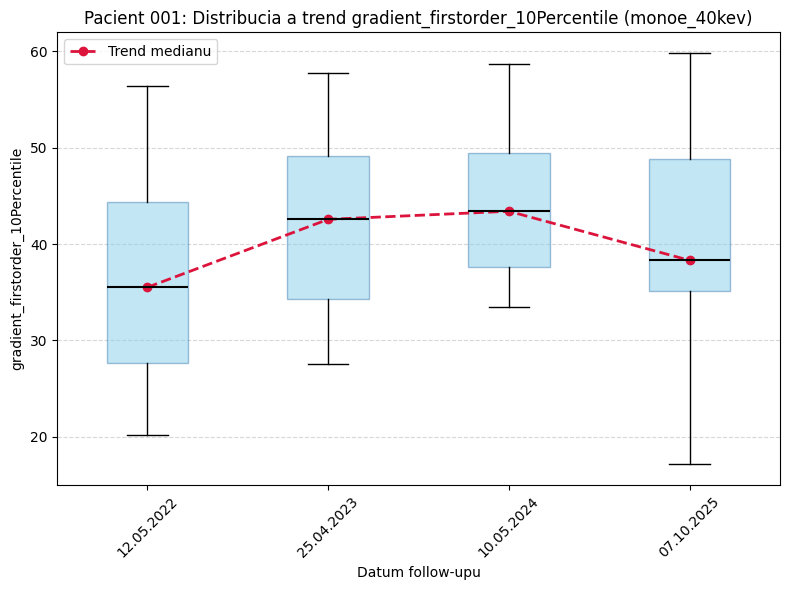

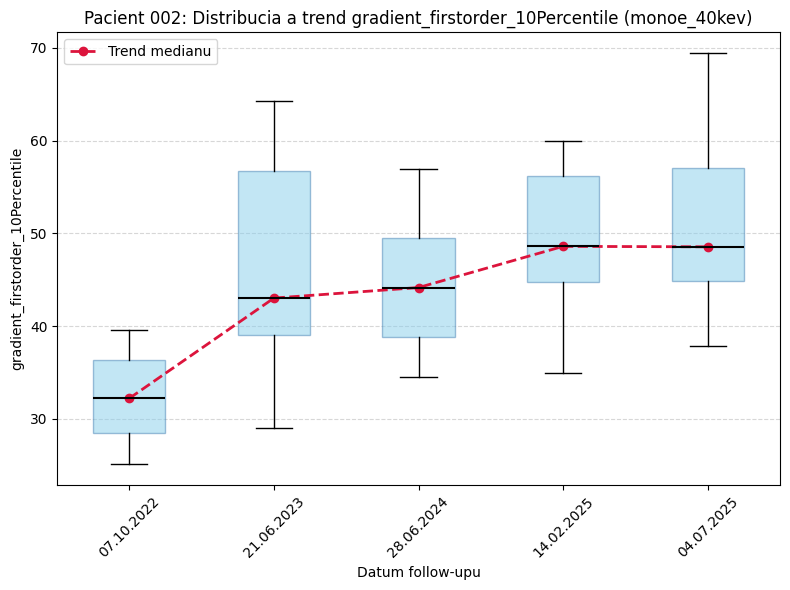

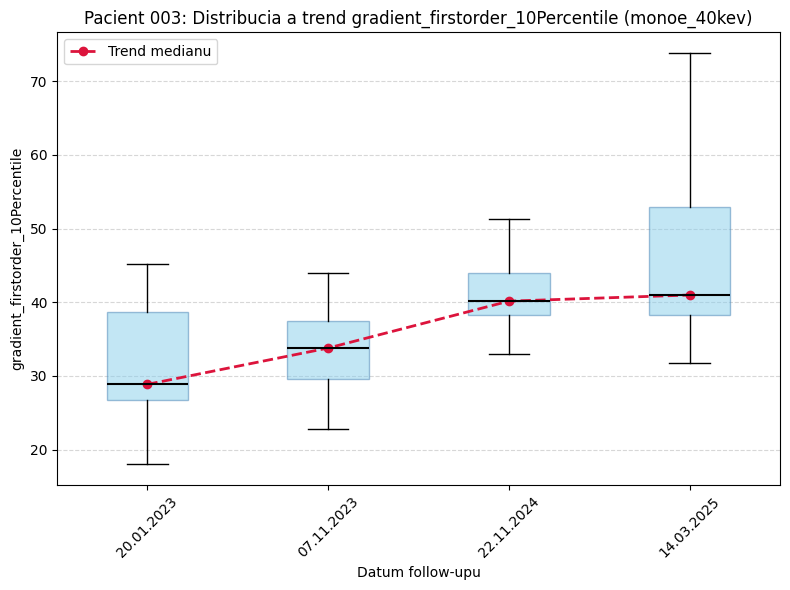

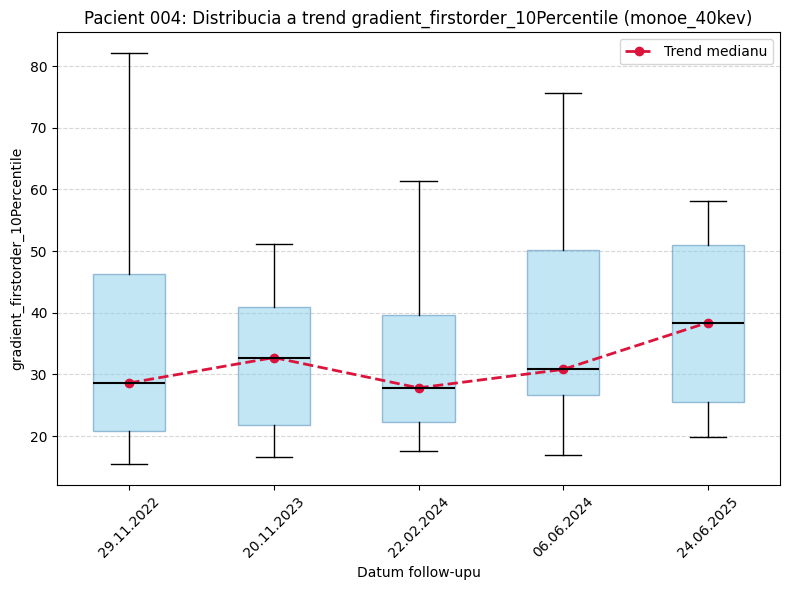

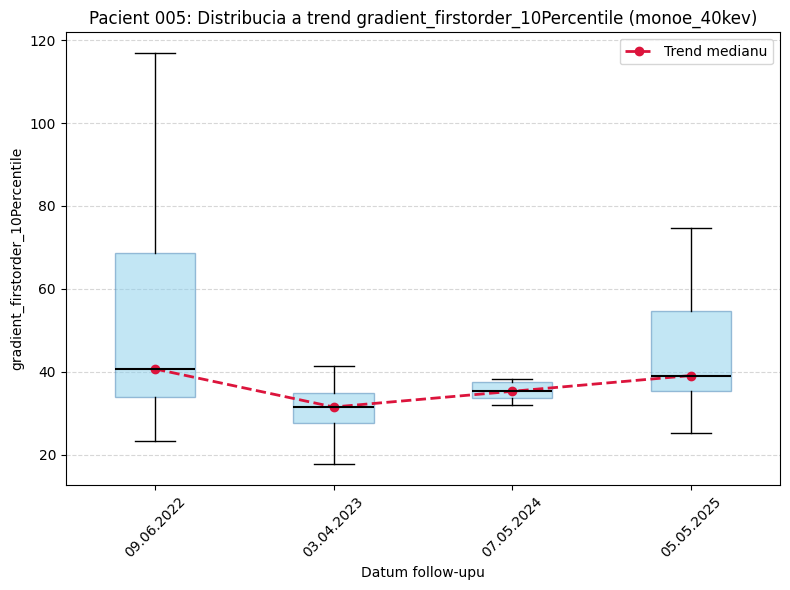

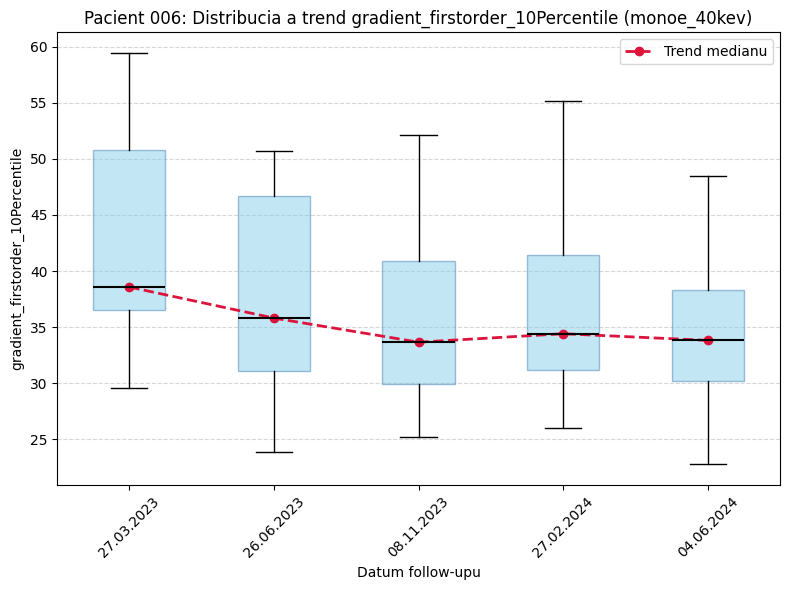

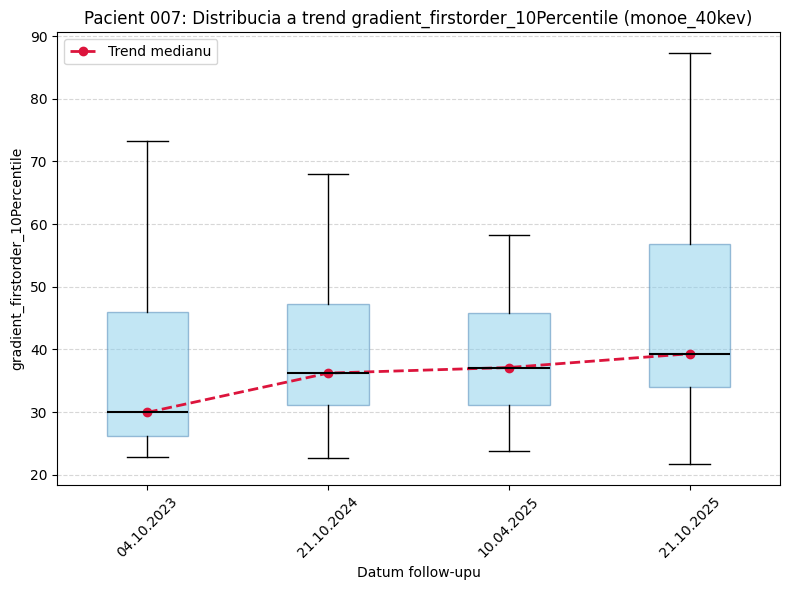

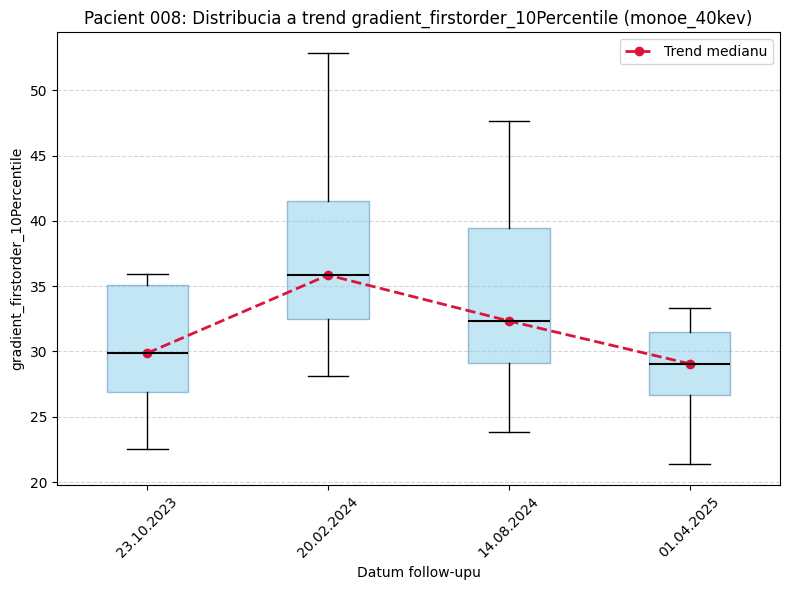

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Nastavenia
plt.style.use('default')
img_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

for patient, followups in patient_follow_up_dfs[img_type].items():
    all_followup_data = []
    labels = []
    medians_for_trend = []

    for followup_id, df in sorted(followups.items()):
        if df.empty:
            continue

        values = df[feature].dropna().values

        if len(values) > 0:
            all_followup_data.append(values)
            # Vypo﷿﷿﷿﷿tame medi﷿﷿n pre tento konkr﷿﷿tny followup pre ﷿﷿iaru trendu
            medians_for_trend.append(np.median(values))

            date = pd.to_datetime(df["Date"].iloc[0], dayfirst=True)
            labels.append(date.strftime('%d.%m.%Y'))

    if all_followup_data:
        plt.figure(figsize=(8, 6))

        # 1. Vykreslenie boxplotov
        # Poz﷿﷿cie boxov s﷿﷿ automaticky [1, 2, 3, ...]
        plt.boxplot(all_followup_data,
                    tick_labels=labels,
                    patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    boxprops=dict(facecolor="skyblue", color="steelblue", alpha=0.5),
                    showfliers=False) # Zobraz﷿﷿ outliery ako bodky

        # 2. Vykreslenie ﷿﷿iary trendu (medi﷿﷿nu)
        # X-ov﷿﷿ s﷿﷿radnice musia by﷿﷿ od 1 do po﷿﷿tu followupov
        x_axis_positions = range(1, len(all_followup_data) + 1)
        plt.plot(x_axis_positions, medians_for_trend,
                 marker="o", color="crimson", linewidth=2,
                 label="Trend medianu", linestyle="--")

        plt.xlabel("Datum follow-upu")
        plt.ylabel(feature)
        plt.title(f"Pacient {patient}: Distribucia a trend {feature} ({img_type})")

        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        plt.legend()

        plt.tight_layout()
        plt.show()

skusit na urovni lezi

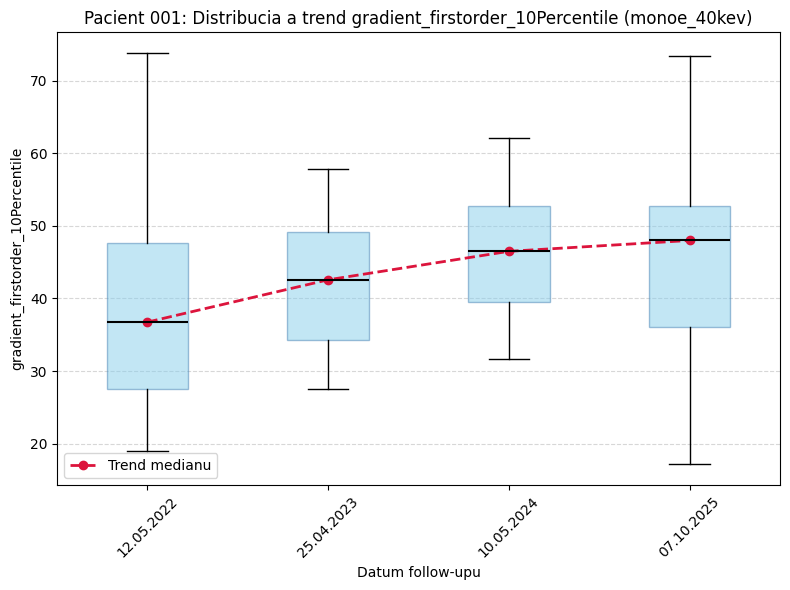

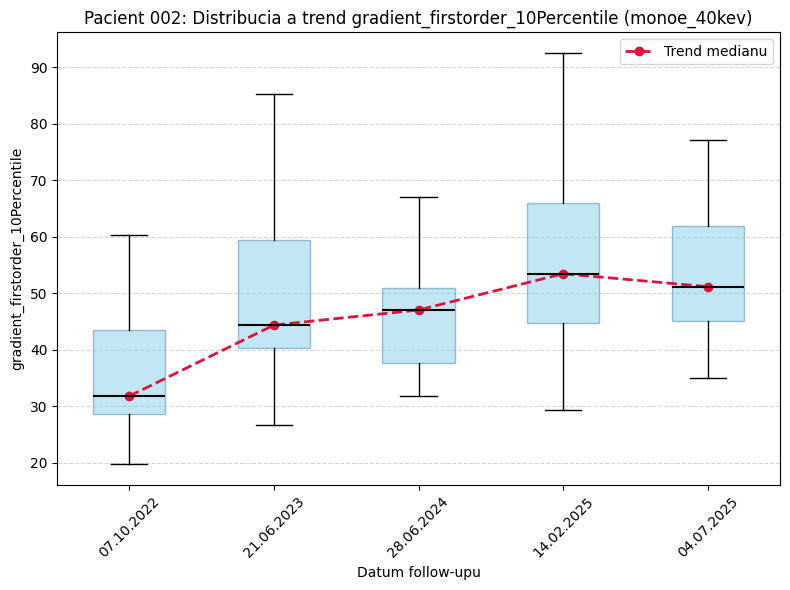

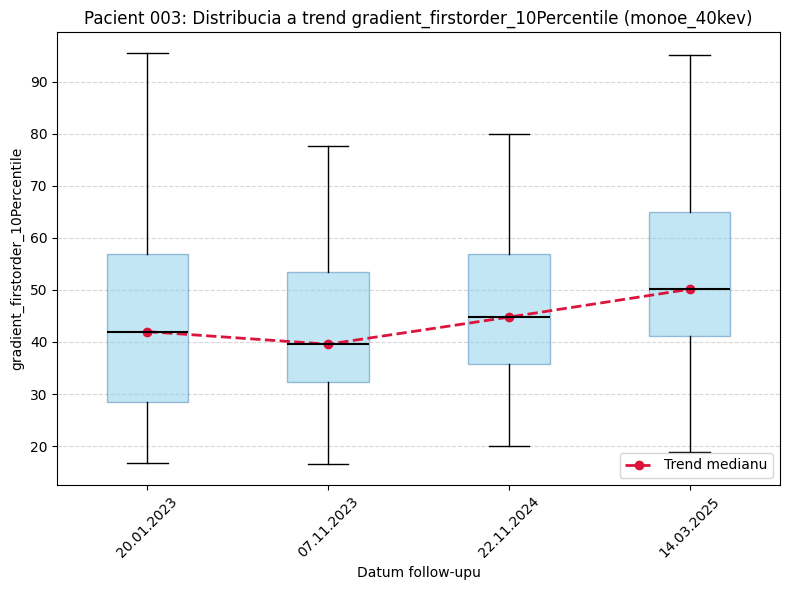

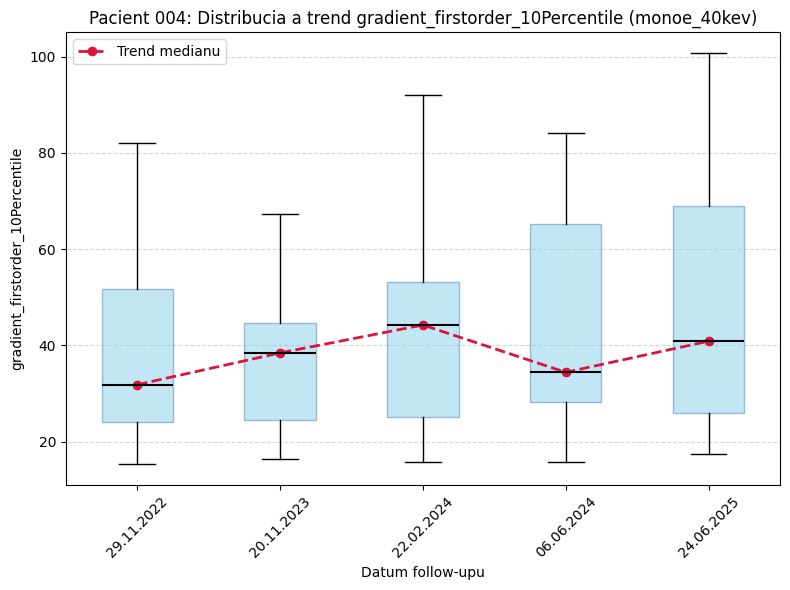

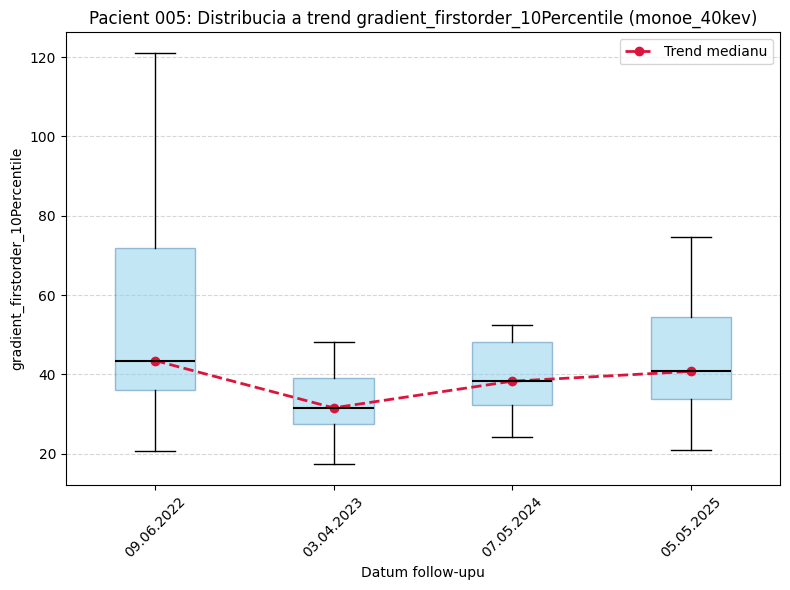

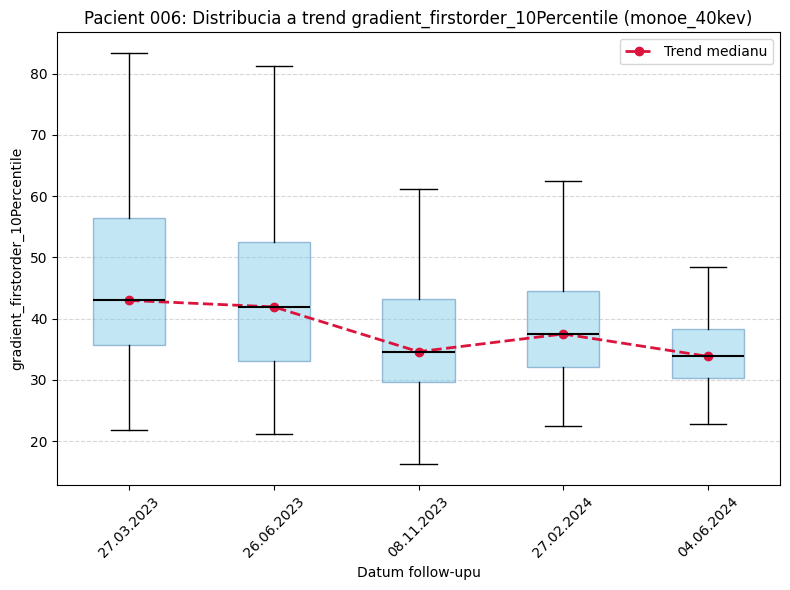

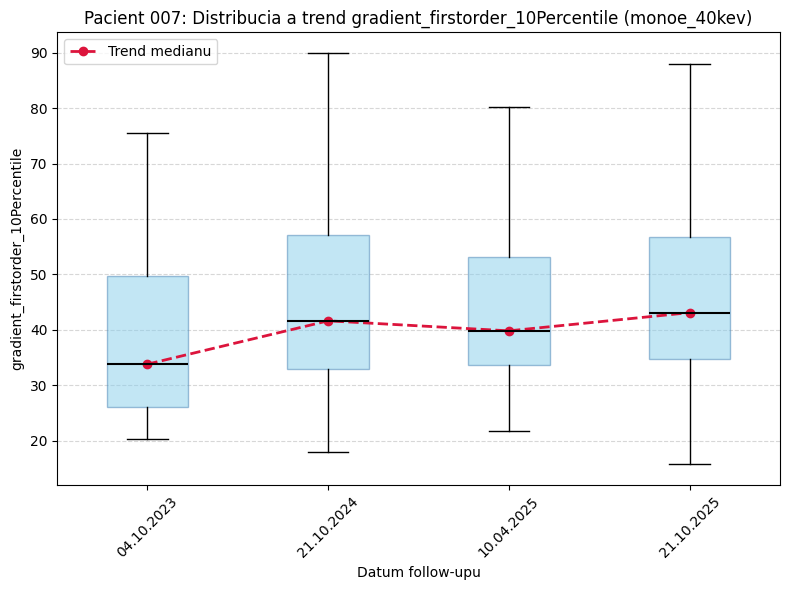

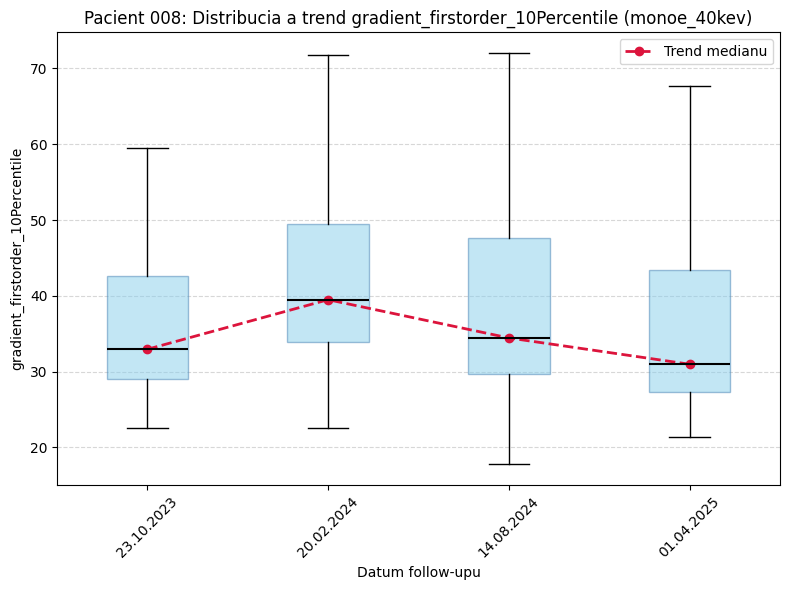

In [18]:
import os
import re
import pandas as pd
from collections import defaultdict

main_folder_path = r"E:\DATA_FollowUp"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]
patients = {img: defaultdict(list) for img in image_types}

pattern = r"Myel_FollowUp_(\d+)_(\d+)"

for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if match:
        patient_id = match.group(1)
        followup_number = int(match.group(2))

        folder_path = os.path.join(main_folder_path, folder)
        for file in os.listdir(folder_path):
            if file.endswith(".csv") and "radiomics_individual_lesion_features" in file:
                for img in image_types:
                    if img in file:
                        csv_path = os.path.join(folder_path, file)
                        patients[img][patient_id].append((followup_number, csv_path))


patient_dates = {
    "001": ["12-05-2022", "25-04-2023", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024", "04-06-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    "008": ["23-10-2023", "20-02-2024", "14-08-2024", "01-04-2025"],
}

patient_follow_up_dfs = {}

for img_type, patient_data in patients.items():
    patient_follow_up_dfs[img_type] = {}

    for patient, scans in patient_data.items():
        scans = sorted(scans, key=lambda x: x[0])
        patient_follow_up_dfs[img_type][patient] = {}

        for i, (followup, path) in enumerate(scans):
            df = pd.read_csv(path)
            df["Date"] = patient_dates[patient][i]
            patient_follow_up_dfs[img_type][patient][followup] = df


import matplotlib.pyplot as plt
import numpy as np

# Nastavenia
plt.style.use('default')
img_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

for patient, followups in patient_follow_up_dfs[img_type].items():
    all_followup_data = []
    labels = []
    medians_for_trend = []

    for followup_id, df in sorted(followups.items()):
        if df.empty:
            continue

        values = df[feature].dropna().values

        if len(values) > 0:
            all_followup_data.append(values)
            # Vypo﷿﷿﷿﷿tame medi﷿﷿n pre tento konkr﷿﷿tny followup pre ﷿﷿iaru trendu
            medians_for_trend.append(np.median(values))

            date = pd.to_datetime(df["Date"].iloc[0], dayfirst=True)
            labels.append(date.strftime('%d.%m.%Y'))

    if all_followup_data:
        plt.figure(figsize=(8, 6))

        # 1. Vykreslenie boxplotov
        # Poz﷿﷿cie boxov s﷿﷿ automaticky [1, 2, 3, ...]
        plt.boxplot(all_followup_data,
                    tick_labels=labels,
                    patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    boxprops=dict(facecolor="skyblue", color="steelblue", alpha=0.5),
                    showfliers=False) # Zobraz﷿﷿ outliery ako bodky

        # 2. Vykreslenie ﷿﷿iary trendu (medi﷿﷿nu)
        # X-ov﷿﷿ s﷿﷿radnice musia by﷿﷿ od 1 do po﷿﷿tu followupov
        x_axis_positions = range(1, len(all_followup_data) + 1)
        plt.plot(x_axis_positions, medians_for_trend,
                 marker="o", color="crimson", linewidth=2,
                 label="Trend medianu", linestyle="--")

        plt.xlabel("Datum follow-upu")
        plt.ylabel(feature)
        plt.title(f"Pacient {patient}: Distribucia a trend {feature} ({img_type})")

        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        plt.legend()

        plt.tight_layout()
        plt.show()

skusit rozdelit obratle podla trendu

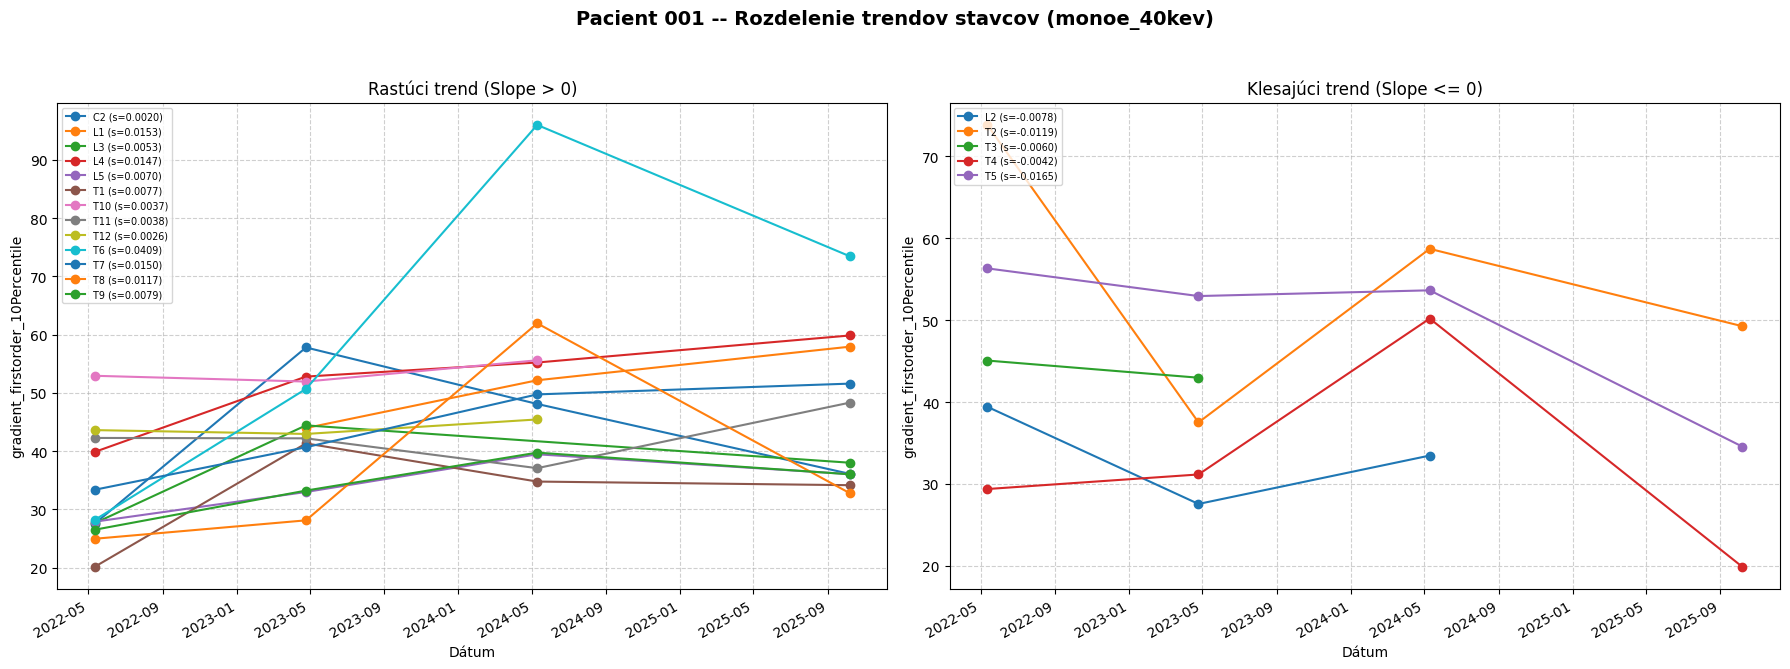

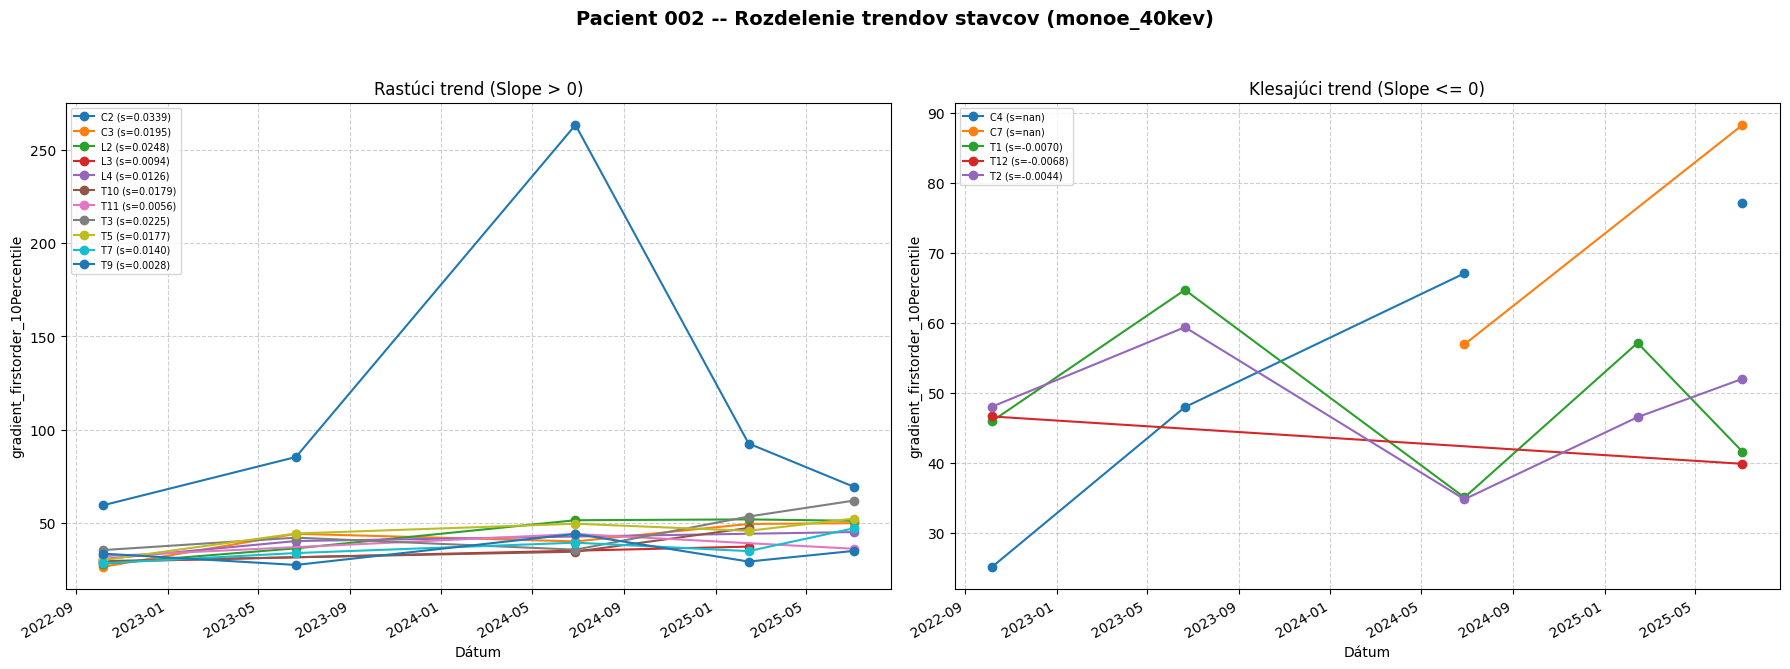

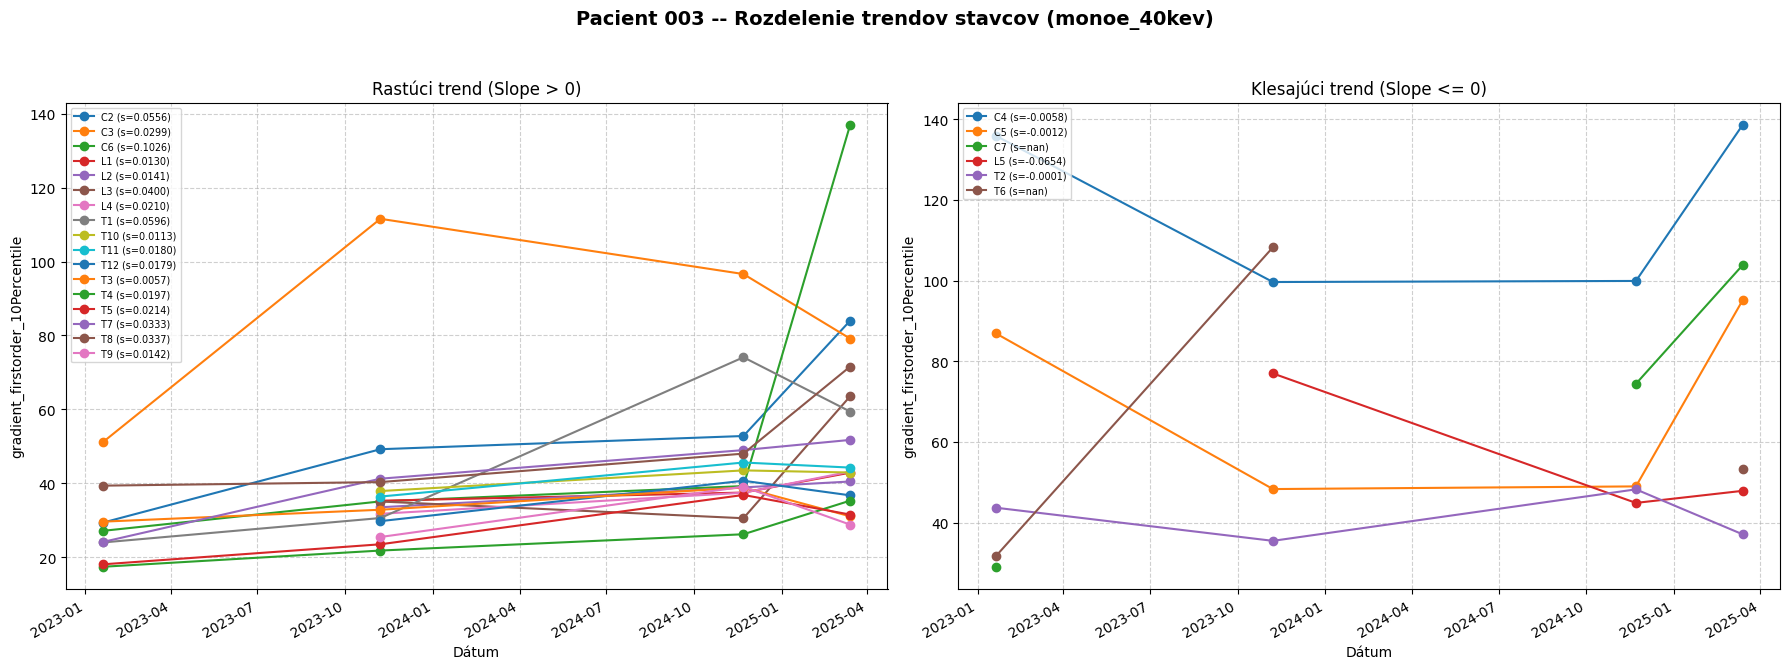

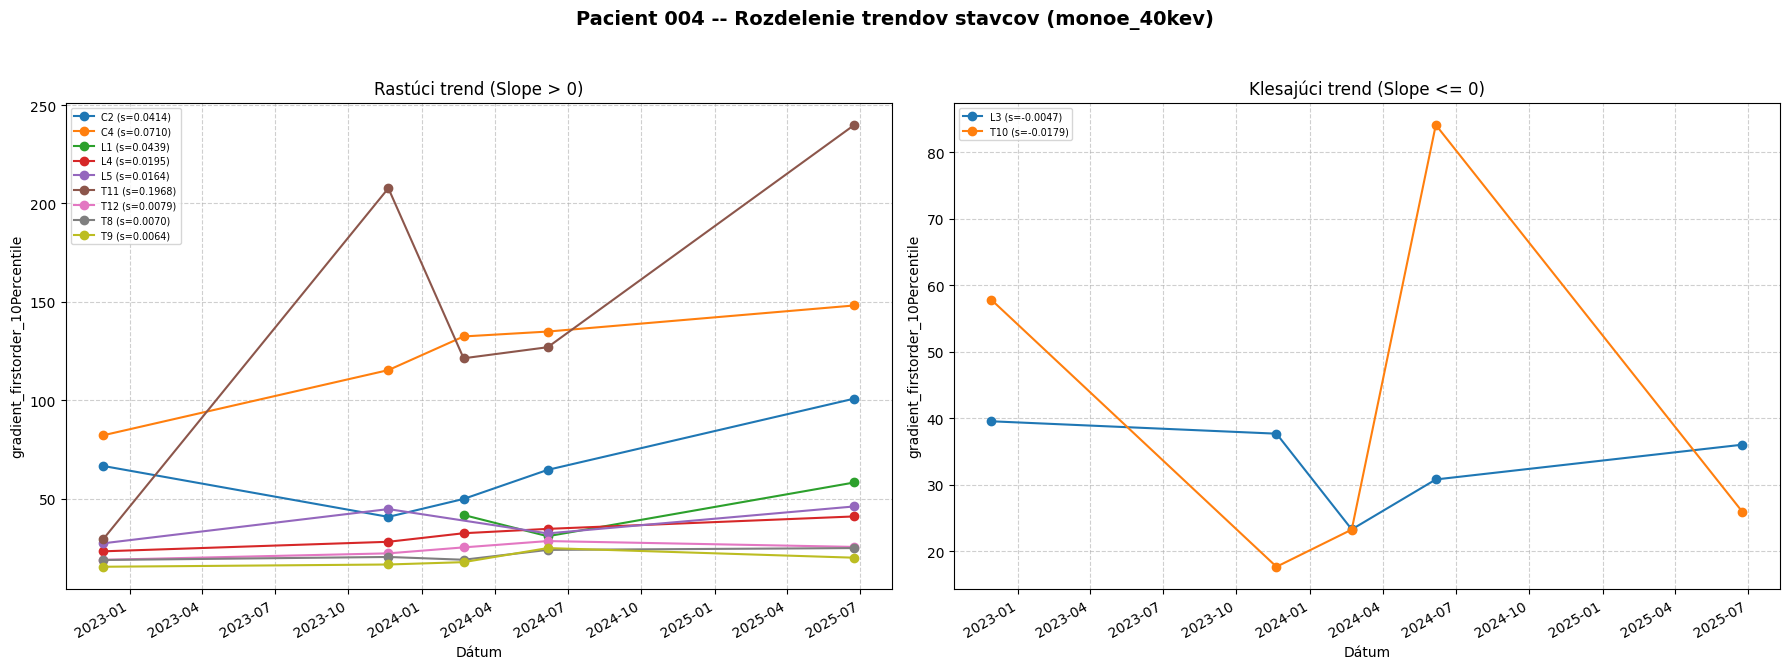

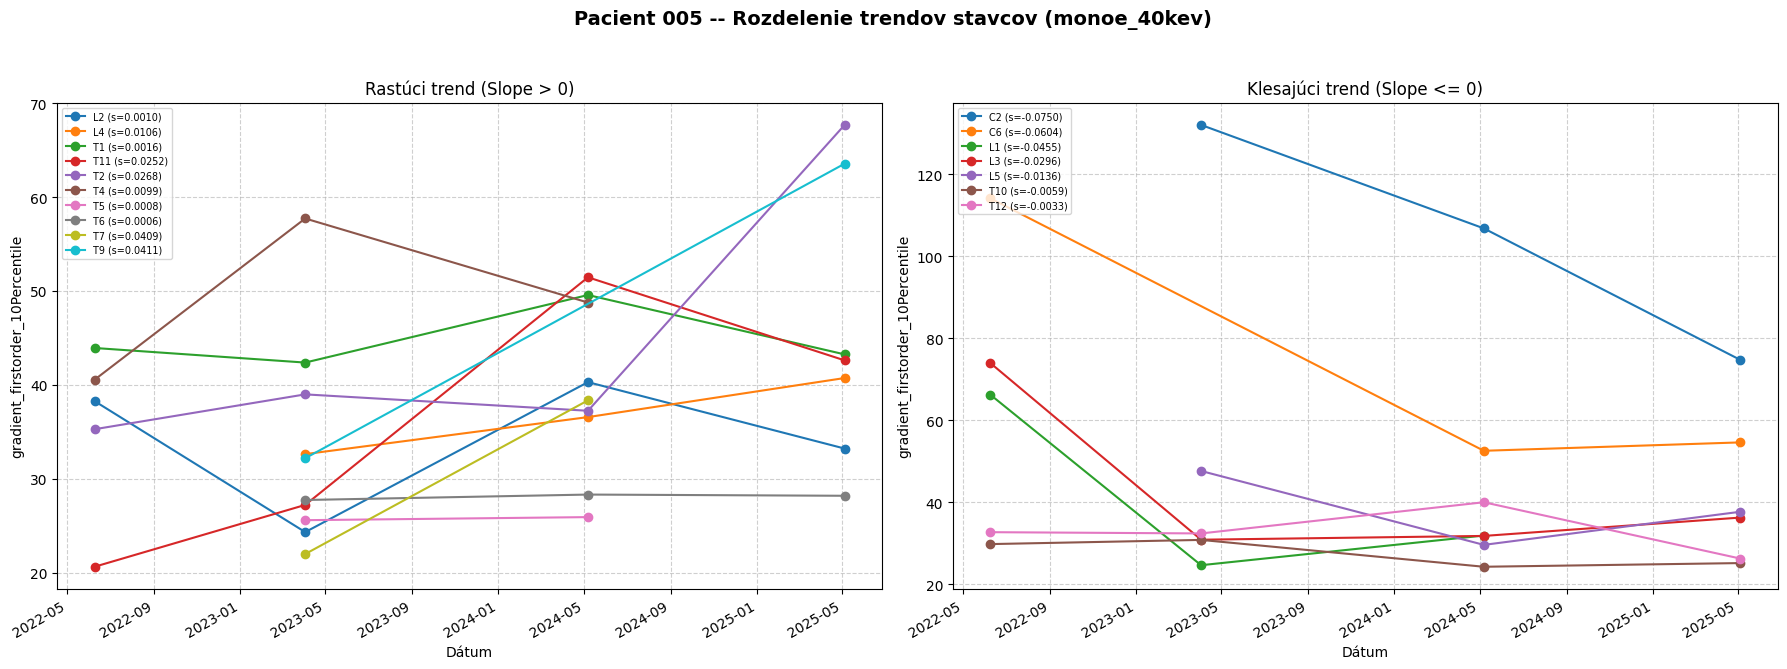

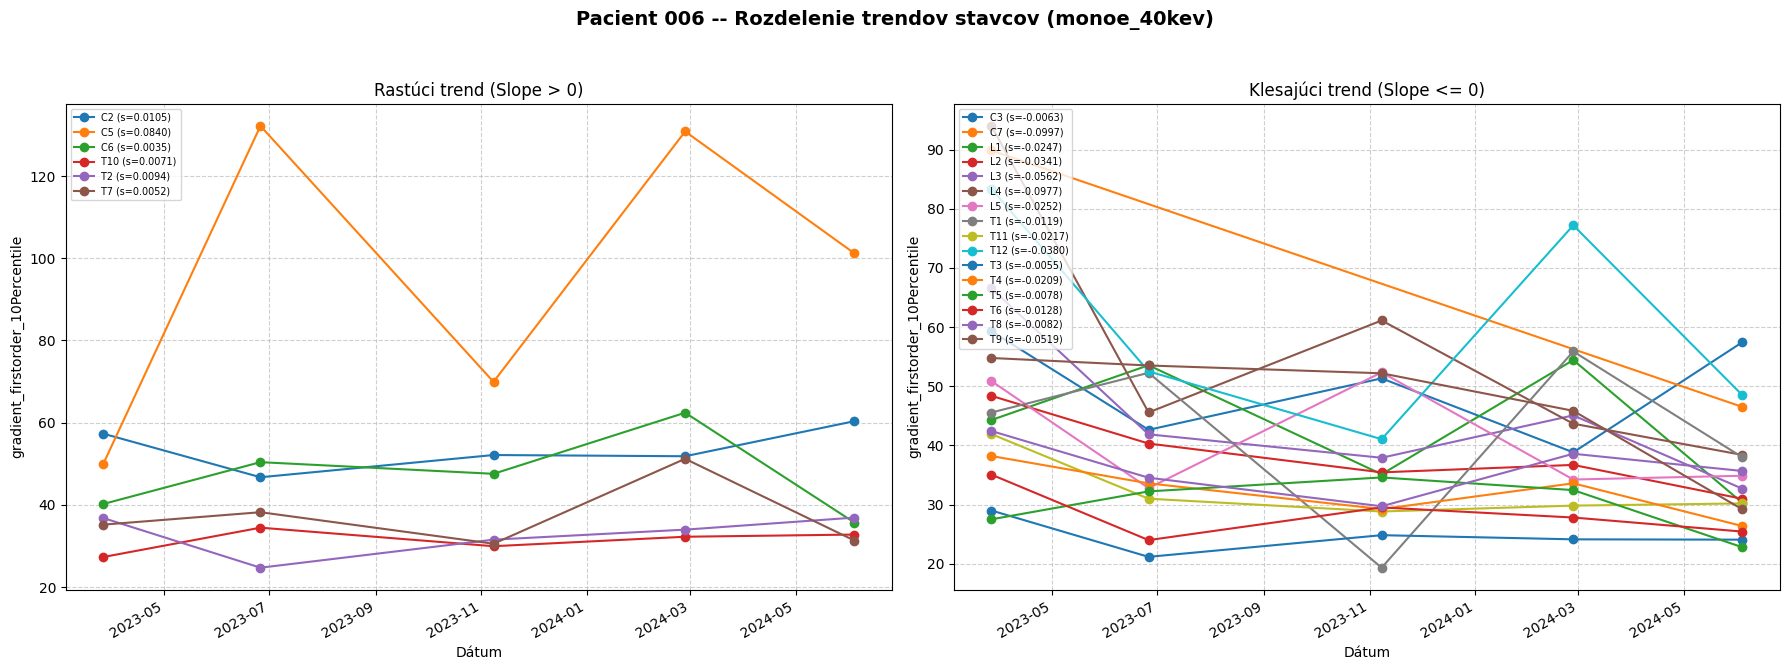

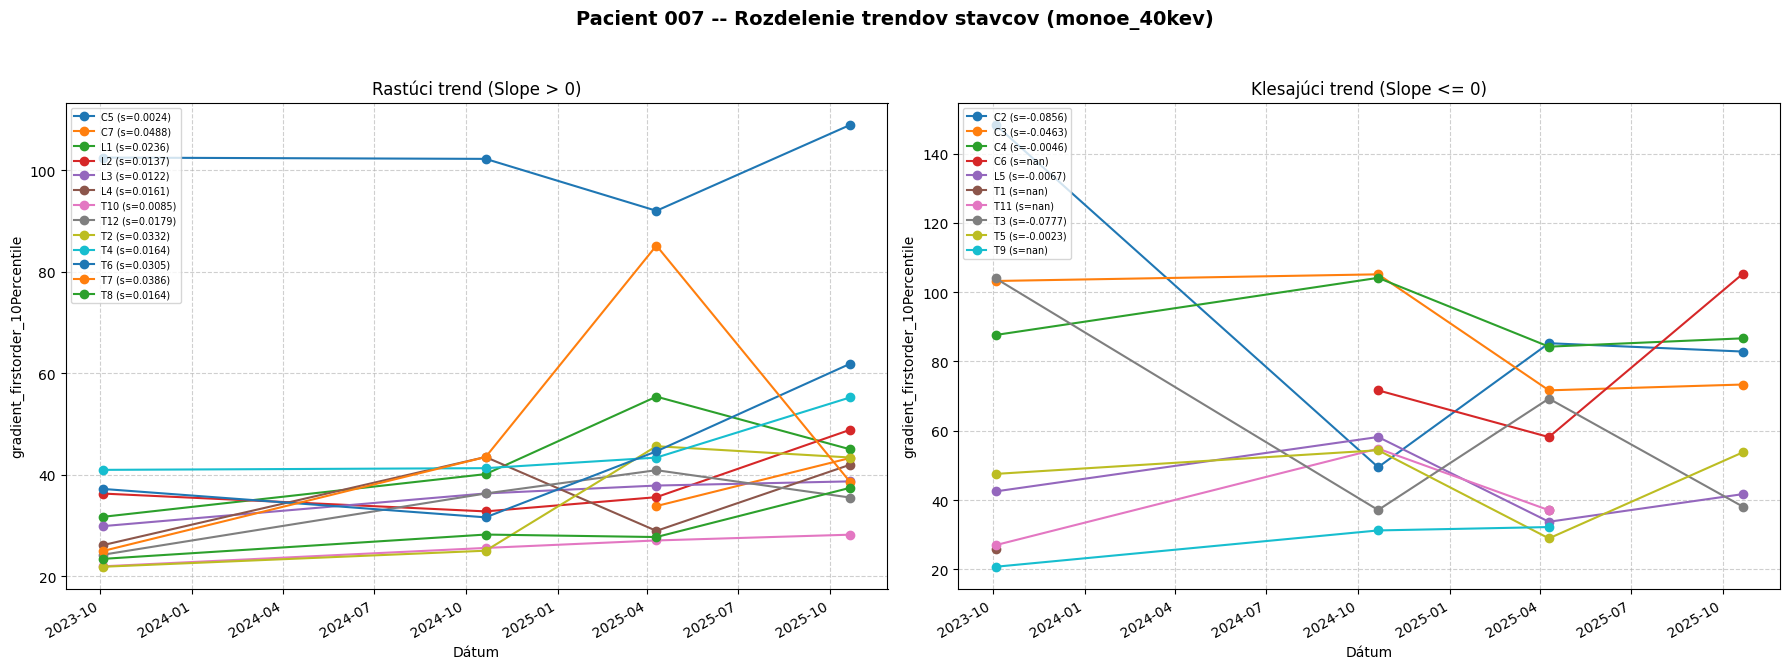

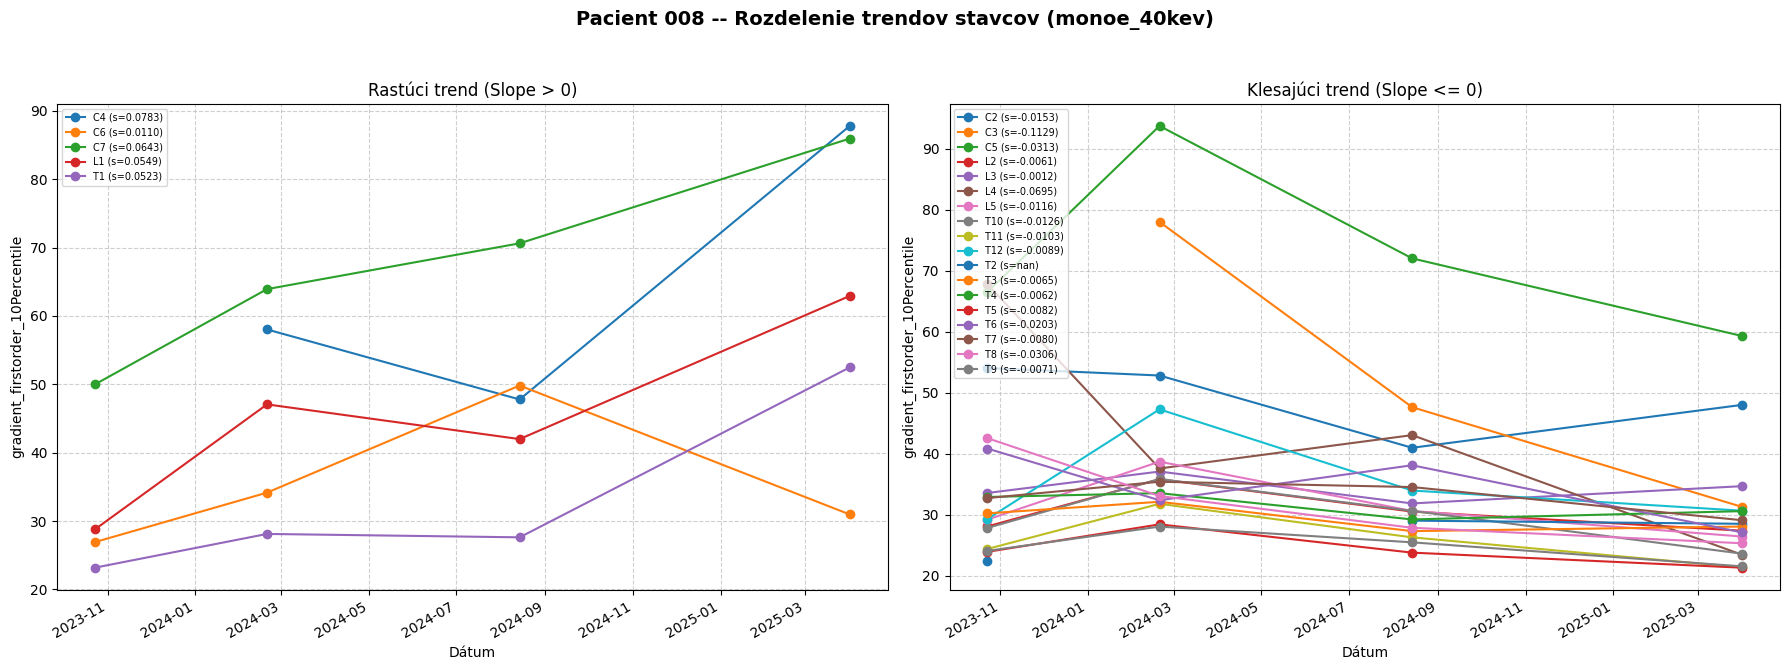

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Nastavenia
plt.style.use('default')
img_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"
vertebra_col = "vertebra_name"

for patient, followups in patient_follow_up_dfs[img_type].items():

    # 1. Analýza trendov pre všetky stavce
    increasing_data = {}
    decreasing_data = {}

    all_vertebrae = set()
    for df in followups.values():
        all_vertebrae.update(df[vertebra_col].unique())

    for vertebra in sorted(all_vertebrae):
        dates, values = [], []
        for followup, df in sorted(followups.items()):
            row = df[df[vertebra_col] == vertebra]
            if row.empty: continue

            dates.append(pd.to_datetime(row["Date"].iloc[0], dayfirst=True))
            values.append(row[feature].iloc[0])

        if len(dates) > 1:
            # Výpočet smernice (slope)
            days_from_start = [(d - dates[0]).days for d in dates]
            slope, _ = np.polyfit(days_from_start, values, 1)

            entry = {"dates": dates, "values": values, "slope": slope}
            if slope > 0:
                increasing_data[vertebra] = entry
            else:
                decreasing_data[vertebra] = entry

    # 2. Vykreslenie - dva podgrafy vedľa seba
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

    # Pomocná štruktúra pre cyklus vykresľovania
    plot_configs = [
        (ax1, increasing_data, "Rastúci trend (Slope > 0)", "Greens"),
        (ax2, decreasing_data, "Klesajúci trend (Slope <= 0)", "Reds")
    ]

    for ax, data_group, title_suffix, cmap in plot_configs:
        if data_group:
            for vertebra, d in data_group.items():
                ax.plot(d["dates"], d["values"], marker="o", label=f"{vertebra} (s={d['slope']:.4f})")

            ax.set_title(f"{title_suffix}")
            ax.set_xlabel("Dátum")
            ax.set_ylabel(feature)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend(loc="upper left", fontsize='x-small', ncol=1)
            # Formátovanie dátumov pre konkrétnu os
            plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
        else:
            ax.text(0.5, 0.5, "Žiadne dáta v tejto kategórii",
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{title_suffix} (Prázdne)")

    plt.suptitle(f"Pacient {patient} -- Rozdelenie trendov stavcov ({img_type})", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Necháme priestor pre suptitle
    plt.show()

zistit preco su niektore obratle outliers

- 001 -> C2 = Tmave leze
- 002 -> C2 = Tmave leze
- 003 -> C3 = Tmave leze
- 004 -> T11 = Tmave leze
- 006 -> C5 = Tmave leze
- 7, 8 = Tmave leze